## Script to process multiple years for a GHCND location using a Fourier Series Fit to the Temp Time Series, generate diagnostic plots, and some maps



In [177]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess

import warnings
warnings.filterwarnings('ignore')

In [332]:


###################
# helper functions
###################
def SummerStatsFourier(temp_data, temp_data_next, threshold, save_plot, calc_tmax, calc_heat, NH):
    '''

    Function that uses the input 75th percentile temperature in K to identify the summer from a time series of temperatures.
    Input data should already be set to 365 days.

    Args:
        temp_data: xarray of temperature data for a single grid cell for the year of interest
        temp_data_next: xarray of temperature data for a single grid cell for the following year (for SH summers)
        threshold: xarray for the 75th percentile threshold to use
        save_plot: save out a png of the time series with threshold, day of max, summer start/end shown
        calc_tmax: should the day of max temp during summer be calculated (slows processing)
        calc_heat: should the accumulated heat during summer be calculated (slows processing), includes mean temp and mean HS temp
        nh: boolean for whether the location is in the NH or not (if not then we need to use current and next year's data for SH summer)
        
    Returns:
        start day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed above threshold (75th percentile)
        end day: DOY that daily mean t2m (from smoothed Fourier fit) first crossed below threshold (75th percentile) 
        day with max temp: during the summer period, the day that had the highest mean daily t2m 
        accumulated heat in summer: sum of degree days above threshold during summer, 0 if none
        summer length: number of days the smoothed polynomial fit to the t2m data is above threshold, 0 if none
        rmse: root mean squared error of Fourier fit to temperature time series
        **** r2: R-squared value for Fourier fit [IS THIS POSSIBLE???]
        mean temp: the mean temperature in K for the summer period, 0 if there was no time above threshold
        mean HS temp: the mean temperature in K for the days above threshold during summer (positive days)
        
    Example:
        start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStats(temps, temps_next, thresh, True, True, False, True)

    '''

    # default values
    first_day = 0 
    last_day = 0
    tmax_day = 0 
    summer_heat = 0 
    summer_length = 0
    rmse = 0.0
    r_squared = 0.0 # keeping for backward compat with the poly fit outputs
    mean_t = 0
    mean_hs = 0

    # split method based on NH or SH

    ######
    # Northern Hemisphere (uses current year only)
    if NH:
        # extract DOY and T2m values for those days
        x1 = temp_data.time.dt.dayofyear.values
        y1 = temp_data.values
        #print(x1)
        #print(y1)

        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
    
        # create some x values for plotting polynomial fit
        x_values = np.linspace(min(x1), max(x1), 365) 
    
        # use fit to get stats
        summer_length = np.count_nonzero(y_lp >= threshold.values)
        summer_days = np.where(y_lp >= threshold.values)[0]

        # deal with those that didn't have any days above threshold
        if summer_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(temp_data.argmax() + 1)
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # in this case there are none
                summer_heat = 0
        else:
            # otherwise can get start/end days 
            first_day = int(x_values[min(summer_days)])
            #OLD:# last_day = int(x_values[max(summer_days)])

            # end day comes after first day so find next crossing of fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[first_day:365]) < threshold.values)

            # if it does cross back below threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back below threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # summer length is the span between first and last + 1 to include the end day
            summer_length = last_day - first_day + 1    
            
            if calc_tmax:
                # day with max temp that is in summer period
                if first_day == last_day: #only one day of summer
                    tmax_day = first_day
                else:
                    # if summer_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (temp_data[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((temp_data[(first_day):(last_day+1)].argmax() + 1) + first_day)        
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # also save mean temp
                nh_summ = temp_data[(first_day):(last_day+1)]

                # total area relative to zero for regions above threshold line
                above_thresh = float(nh_summ.where(nh_summ.values >= threshold.values).sum())
                days_above_thresh = nh_summ.where(nh_summ.values >= threshold.values).count()
                
                # area below threshold line to be subtracted
                thresh_heat = float(nh_summ.where(nh_summ.values >= threshold.values).count()) * threshold.values
                
                # calculate difference to get only the area between threshold and data
                summer_heat = above_thresh - thresh_heat

                # if there is a summer we can get the mean temp for the whole summer and the mean HS temp
                if len(nh_summ) > 0:
                    mean_t = nh_summ.values.mean()
                    mean_hs = float(above_thresh/days_above_thresh) - threshold.values

                
    
    ######
    # Southern Hemisphere (uses current year and following year)
    else: 
        # concat both years
        ds_two = xr.concat([temp_data, temp_data_next], dim="time")

        # get the current year for slicing
        input_year = temp_data.time.dt.year.values[0]

        # select July 1 - June 30 across the two years to do fit
        startdate = str(input_year)+'-07-01' # 182nd day of a normal year
        enddate = str(input_year+1)+'-06-30'

        
        sh_yr = ds_two.sel(time=slice(startdate,enddate))

        #print(sh_yr)
        
        # DOY (relative to July 1) and T2m values for those days
        x1 = np.arange(1,len(sh_yr.time)+1) 
        y1 = sh_yr.values
        
        # Fourier fit, up to 4th harmonic (mean + 3 more) as in Weller et al 2020
        ymean = np.mean(y1)
        y_norm = y1 - ymean
        # perform DFT of temp data
        coef = fft(y_norm)
        # low-pass filter: retain only the mean and the first three harmonics, set all other frequencies to zero
        # help from https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week6/filtering_in_freq2.html
        Z_lp = np.copy(coef)
        Z_lp[4:-3:] = 0.0  # we have to set both the positive and negative frequencies to zero
        # apply inverse fourier transform to convert back to time domain (just want the real part)
        y_norm_lp = np.real(np.fft.ifft(Z_lp))

        # add back in the original mean temp
        y_lp = y_norm_lp + ymean

        # RMSE for Fourier fit
        rmse = np.sqrt(np.sum((y1-y_lp)**2)/365.0)
        
        # create some x values for plotting polynomial fit
        x_values = np.linspace(min(x1), max(x1), 365) 
        summer_length = np.count_nonzero(y_lp >= threshold.values)
        summer_days = np.where(y_lp >= threshold.values)[0]

        # check if summer length is 0
        if summer_length == 0:
            first_day = 0
            last_day = 0
            if calc_tmax:
                # day with max temp isn't above threshold but still want the value so can be any day of the year
                tmax_day = int(sh_yr.argmax() + 1)
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # in this case there are none
                summer_heat = 0
        else:
            # otherwise can get start/end days but note these are relative to July 1
            first_day = int(x_values[min(summer_days)])
            #OLD:# last_day = int(x_values[max(summer_days)])

            # end day comes after first day so find next crossing of poly fit
            # this is to be careful to not count until the end of a double crossing
            end_window = np.where((y_lp[first_day:365]) < threshold.values)

            # if it does cross back below threshold before the end of the "year"
            if np.count_nonzero(end_window):
                last_day = end_window[0][0] + first_day

            # otherwise it never crosses back below threshold for the "year"
            # so the last day is day 365
            else:
                last_day = 365
           
            # summer length is the span between first and last + 1 to include the end day
            summer_length = last_day - first_day + 1           
    
            
            if calc_tmax:
                # day with max temp that is in summer period
                if first_day == last_day: #only one day of summer
                    tmax_day = first_day
                else:
                    # if summer_length is 0 then we already grab the day of max temp in the year
                    # but the day of max can also be the last day of the year so have to special case
                    if (sh_yr[(first_day):(last_day+1)]).size == 0:
                        tmax_day = last_day
                    else:         
                        tmax_day = int((sh_yr[(first_day):(last_day+1)].argmax() + 1) + first_day)  
            if calc_heat:
                # determine accumulated heat over summer as sum of degree days above threshold
                # also save the mean temp of summer
                sh_summ = sh_yr[(first_day):(last_day+1)]

                # total area relative to zero for regions above threshold line
                above_thresh = float(sh_summ.where(sh_summ.values >= threshold.values).sum())
                days_above_thresh = sh_summ.where(sh_summ.values >= threshold.values).count()
                
                # area below threshold line to be subtracted
                thresh_heat = float(sh_summ.where(sh_summ.values >= threshold.values).count()) * threshold.values
                
                # calculate difference to get only the area between threshold and data
                summer_heat = above_thresh - thresh_heat

                # if there is a summer we can get the mean temp for the whole summer and the mean HS temp
                if len(sh_summ) > 0:
                    mean_t = sh_summ.values.mean()
                    mean_hs = float(above_thresh/days_above_thresh) - threshold.values
                
                

                
    # make and save plot if desired
    ##
    ##
    if save_plot:
        #cell_lat = temp_data.lat.values
        #cell_lon = temp_data.lon.values
        yr = temp_data.time.dt.year.values[0]

        plt.figure(figsize=(16,6))
        plt.plot(x1,y1, label='daily mean T2m')
        plt.plot(x_values, y_lp, label='Fourier fit 1-4th Harmonic', color='red')
        plt.axhline(threshold.values, color="black", linewidth=0.8, linestyle="dashed") 
        plt.axvline(first_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.axvline(last_day, color="black", linewidth=0.8, linestyle="dashed")
        plt.annotate('start', xy=(first_day-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('end', xy=(last_day-5,np.max(y_lp)+2), fontsize=12)
        plt.annotate('summer = '+str(summer_length)+' days', xy=(first_day+5,np.mean(y_lp)), fontsize=18)
        plt.annotate('75th percentile = '+str(np.round(threshold.values,1))+'K', xy=(0,threshold.values+1), fontsize=18)
        plt.annotate('RMSE = '+str(np.round(rmse,2)), xy=(0, np.min(y1)), fontsize=18)
        plt.annotate('Mean = '+str(np.round(mean_t,2))+'K', xy=(last_day-5, mean_t-1), fontsize=12)

        if calc_tmax:
            # add annotation for tmax_day
            plt.annotate('Tmax day '+str(tmax_day), xy=(tmax_day,np.max(y1)), fontsize=12)

        if not NH:
            # SH days are relative to July 1
            plt.xlabel('DOY (' + str(yr) + ') relative to July 1')
        else:
            plt.xlabel('DOY (' + str(yr) + ')')
        plt.ylabel('Mean Daily Temp (K)')
        plt.title(str(yr) + " Summer: Baseline Years = (1961-1990)")
        plt.legend()
        #plt.savefig("fourierfit_stats_"+str(cell_lat)+"_"+str(cell_lon)+"_"+str(yr)+".png")
        plt.show()
    
    # return
    return int(first_day), int(last_day), int(tmax_day), float(summer_heat), int(summer_length), float(rmse), float(r_squared), float(mean_t), float(mean_hs)


# a function that takes in a dataset of global t2m values and if it is a leap year averages
# the temps on Feb 28 & Feb 29, then drops Feb 29 to ensure the year has 365 days
def HandleLeapYears(input_ds):
    '''

    Function that takes the mean of Feb 28 & Feb 29 (if it exists) and returns an xarray Dataset that has 365 days
    where Feb 28 will now have a t2m value that is the mean of Feb 28 & Feb 29

    Args:
        input_ds: the data set containing a single year of data that may need adjusting for leap year
        
    Returns:
        output_ds
        
    Example:
        no_leap_ds = HandleLeapYears(input_ds)

    '''
    

    # check if a leap year
    if(input_ds.time.dt.is_leap_year[0].values):
        
        # make deep copy
        output_ds = input_ds.copy(deep=True)
        
        # get mean of Feb 28 (time index 58) & Feb 29 (time index 59) for each grid cell and overwrite Feb 28 with it
        mean_dat = output_ds.tavg[58:60].mean(dim='time', skipna=True, keep_attrs=True)
        output_ds.tavg[58] = mean_dat
        
        # drop Feb 29
        output_ds = output_ds.convert_calendar('noleap', use_cftime=None)

        # ensure time is datetime64
        output_ds["time"] = output_ds.time.dt.strftime('%Y-%m-%d')
        output_ds['time'] = pd.to_datetime(output_ds['time'])

        # return the new dataset 
        return output_ds
    else:
        return input_ds
    

## Example API query to pull data from NCEI:  https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TAVG,TMAX,TMIN&stations=CA001108465&startDate=1961-01-01&endDate=2023-12-31&includeStationLocation=1&units=metric&includeStationName=true&format=csv

## Need to pull in data from GHCND CSV file for a location and process it for summer metrics

## ** St Petersburg ** has complete data

### https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:RSM00026063/detail

In [2]:
df = pd.read_csv("../../../Data/GHCND/st_petersburg-2025-04-03T16-53-51.csv")
df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN
0,RSM00026063,"ST. PETERSBURG, RS",59.9667,30.3,3.0,1961-01-01,-0.5,1.1,-2.3
1,RSM00026063,"ST. PETERSBURG, RS",59.9667,30.3,3.0,1961-01-02,-1.0,0.5,-2.0
2,RSM00026063,"ST. PETERSBURG, RS",59.9667,30.3,3.0,1961-01-03,-0.5,0.5,-2.1
3,RSM00026063,"ST. PETERSBURG, RS",59.9667,30.3,3.0,1961-01-04,-0.6,0.6,-1.8
4,RSM00026063,"ST. PETERSBURG, RS",59.9667,30.3,3.0,1961-01-05,2.0,3.4,0.3
...,...,...,...,...,...,...,...,...,...
23002,RSM00026063,"ST. PETERSBURG, RS",59.9667,30.3,3.0,2023-12-27,-4.5,-2.0,NaN
23003,RSM00026063,"ST. PETERSBURG, RS",59.9667,30.3,3.0,2023-12-28,-3.3,-1.0,-8.8
23004,RSM00026063,"ST. PETERSBURG, RS",59.9667,30.3,3.0,2023-12-29,-2.9,NaN,NaN
23005,RSM00026063,"ST. PETERSBURG, RS",59.9667,30.3,3.0,2023-12-30,-4.3,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23007 entries, 0 to 23006
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   STATION    23007 non-null  object 
 1   NAME       23007 non-null  object 
 2   LATITUDE   23007 non-null  float64
 3   LONGITUDE  23007 non-null  float64
 4   ELEVATION  23007 non-null  float64
 5   DATE       23007 non-null  object 
 6   TAVG       23007 non-null  float64
 7   TMAX       22271 non-null  float64
 8   TMIN       21622 non-null  float64
dtypes: float64(6), object(3)
memory usage: 1.6+ MB


In [90]:
df['TAVG'].to_list()[:5]

[-0.5, -1.0, -0.5, -0.6, 2.0]

In [96]:
df['DATE'] = pd.to_datetime(df['DATE'])
df_sub = pd.DataFrame({'time':df['DATE'],
                      #'lat':df['LATITUDE'],
                      #'lon':df['LONGITUDE'],
                      'tavg':df['TAVG'].to_list()})
df_sub = df_sub.set_index(['time'])#,'lat','lon'])
df_sub['tavg'] = df_sub['tavg'] + 273.15
df_sub

,tavg
time,
1961-01-01,272.65
1961-01-02,272.15
1961-01-03,272.65
1961-01-04,272.55
1961-01-05,275.15
...,...
2023-12-27,268.65
2023-12-28,269.85
2023-12-29,270.25


### Convert from Pandas to XArray

In [97]:
da_stp = df_sub.to_xarray()
da_stp.tavg.attrs['units'] = "Degrees [K]"
da_stp.tavg.attrs['long_name'] = "Mean temperature"
da_stp

<xarray.Dataset> Size: 368kB
Dimensions:  (time: 23007)
Coordinates:
  * time     (time) datetime64[ns] 184kB 1961-01-01 1961-01-02 ... 2023-12-31
Data variables:
    tavg     (time) float64 184kB 272.6 272.1 272.6 272.5 ... 270.2 268.8 262.4

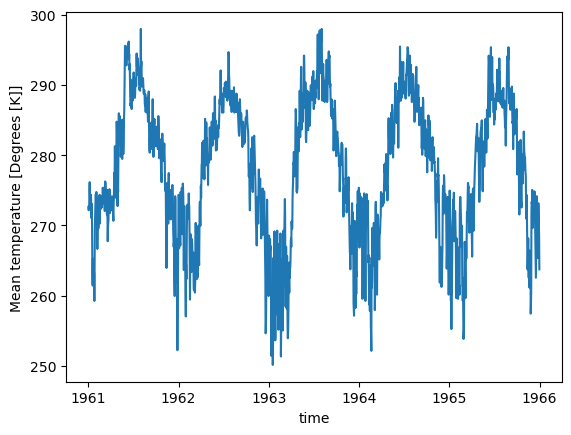

In [98]:
da_stp.tavg.sel(time=slice('1961','1965')).plot()

### Calculate the threshold temp from 1961-1990, 75%-ile

#### Load baseline 75% percentile values per grid cell to see what ERA5 calculated threshold for this lat/lon is

In [113]:
# get baseline
file_path = '../../../Data/ERA5-global/Baseline/computed_1961-1990-full_75th.nc'
c_75 = xr.open_dataarray(file_path)
c_75.values


array([[236.4370575 , 236.4370575 , 236.4370575 , ..., 236.4370575 ,
        236.4370575 , 236.4370575 ],
       [236.18743896, 236.1893158 , 236.19142151, ..., 236.18388367,
        236.18530273, 236.18659973],
       [235.91021729, 235.9200592 , 235.92704773, ..., 235.88049316,
        235.8903656 , 235.90020752],
       ...,
       [270.7281189 , 270.72640991, 270.72720337, ..., 270.73239136,
        270.73184204, 270.73007202],
       [270.74356079, 270.74273682, 270.74200439, ..., 270.74594116,
        270.74508667, 270.74420166],
       [270.7550354 , 270.7550354 , 270.7550354 , ..., 270.7550354 ,
        270.7550354 , 270.7550354 ]])

In [117]:
# get threshold for this location
thresh = c_75.sel(lat=df.LATITUDE[0], lon=df.LONGITUDE[0], method="nearest")
print(thresh)

<xarray.DataArray 't2m' ()> Size: 8B
array(285.329956)
Coordinates:
    lat       float64 8B 60.0
    lon       float64 8B 30.25
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K


####  Calculate it from the observational data instead for comparison

In [99]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
stp_75 = da_stp.tavg.quantile(0.75, dim=('time'))
stp_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
stp_75.attrs["units"] = "K"
stp_75

CPU times: user 2.95 ms, sys: 998 μs, total: 3.95 ms
Wall time: 2.81 ms


<xarray.DataArray 'tavg' ()> Size: 8B
array(287.15)
Coordinates:
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

In [63]:
thresh.values - stp_75.values

array([[-1.82004395]])

#### St Petersburg 75th Percentile from GHCND data is 1.82 K warmer

### Try one year (2023) fit via Fourier

In [118]:
da.tavg.values[0]

np.float64(264.84999999999997)

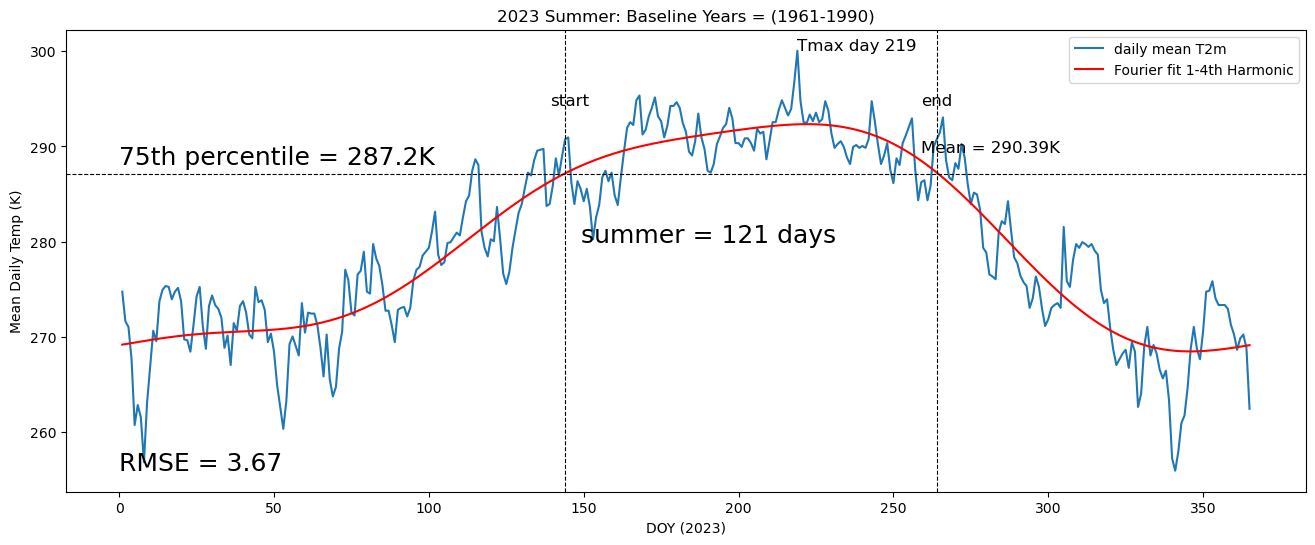

(144,
 264,
 219,
 437.90000000000146,
 121,
 3.6683842001706317,
 0.0,
 290.3888429752065,
 4.379000000000019)

In [124]:
input_year = 2023
da = da_stp.sel(time=str(input_year))
# since this is in the NH don't really need a next year
da_next = da_stp.sel(time=str(input_year))
da = HandleLeapYears(da)
da_next = HandleLeapYears(da_next)

curr = da.tavg
nxt = da_next.tavg
thresh = stp_75
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

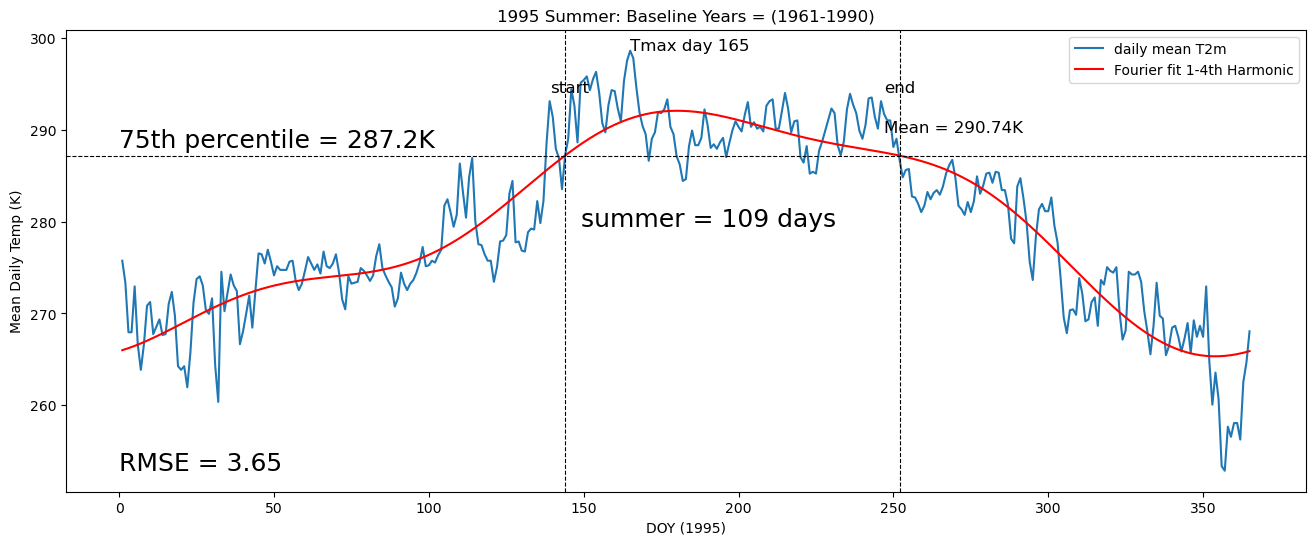

(144,
 252,
 165,
 406.59999999999854,
 109,
 3.649420328476956,
 0.0,
 290.73623853211006,
 4.191752577319562)

In [125]:
# how about 1995
input_year = 1995
da = da_stp.sel(time=str(input_year))
# since this is in the NH don't really need a next year
da_next = da_stp.sel(time=str(input_year))
da = HandleLeapYears(da)
da_next = HandleLeapYears(da_next)

curr = da.tavg
nxt = da_next.tavg
thresh = stp_75
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

### Looks to be working!

### Run through all years now and then uuse ideas from "AnalyzeTrends" script to output the 1961-2023 summer stats aggregated file for analysis

### Main Loop: loop through multiple years to generate summer stats

In [167]:
# testing the construction of the results DF
df_summ = pd.DataFrame({"Year":[],
                        "SummerStart":[],
                        "SummerEnd":[],
                        "SummerLength":[],
                        "SummerAccHeat":[],
                        "SummerTmaxDay":[],
                        "SummerTavg":[]})
print(df_summ)

df_tmp = pd.DataFrame({"Year":int(1990),
                        "SummerStart":4,
                        "SummerEnd":[10],
                        "SummerLength":[6],
                        "SummerAccHeat":[100],
                        "SummerTmaxDay":[5],
                        "SummerTavg":[280]})
df_summ = pd.concat([df_summ, df_tmp])
#df_summ = df_summ.set_index(["Year"])
df_summ

Empty DataFrame
Columns: [Year, SummerStart, SummerEnd, SummerLength, SummerAccHeat, SummerTmaxDay, SummerTavg]
Index: []


,Year,SummerStart,SummerEnd,SummerLength,SummerAccHeat,SummerTmaxDay,SummerTavg
0,1990.0,4.0,10.0,6.0,100.0,5.0,280.0


In [168]:
df_summ["Year"]

0    1990.0
Name: Year, dtype: float64

In [172]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1961, 2024,1)

process_yrs

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [174]:
%%time

# Runtime: XX min for 1 year
# XXX for 10 years
# XXX for 64 years

# empty dataframe for the results
df_summ = pd.DataFrame({"Year":[],
                        "SummerStart":[],
                        "SummerEnd":[],
                        "SummerLength":[],
                        "SummerAccHeat":[],
                        "SummerTmaxDay":[],
                        "SummerTavg":[]})#.set_index(["Year"])


# loop thru the years in the defined array above
for input_year in process_yrs:

    da = da_stp.sel(time=str(input_year))
    # since this is in the NH don't really need a next year
    da_next = da_stp.sel(time=str(input_year))
    da = HandleLeapYears(da)
    da_next = HandleLeapYears(da_next)
    
    curr = da.tavg
    nxt = da_next.tavg
    thresh = stp_75
    start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, False, True, True, True)

    #print(start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs)
    #### Build up a dataframe of the values for later plotting ####
    df_tmp = pd.DataFrame({"Year":[(input_year)],
                        "SummerStart":[(start_day)],
                        "SummerEnd":[(last_day)],
                        "SummerLength":[(summer_length)],
                        "SummerAccHeat":[(acc_heat)],
                        "SummerTmaxDay":[(day_of_max)],
                        "SummerTavg":[(mean_temp)]
                          })#.set_index(["Year"])
    df_summ = pd.concat([df_summ, df_tmp], ignore_index=True)


# output results
df_summ[["Year","SummerStart","SummerEnd","SummerLength","SummerTmaxDay"]] = df_summ[["Year","SummerStart","SummerEnd","SummerLength","SummerTmaxDay"]].astype(int)
df_summ



CPU times: user 275 ms, sys: 6.62 ms, total: 282 ms
Wall time: 280 ms


,Year,SummerStart,SummerEnd,SummerLength,SummerAccHeat,SummerTmaxDay,SummerTavg
0,1961,146,229,84,344.5,213,291.233333
1,1962,169,238,70,95.5,203,288.325714
2,1963,144,260,117,345.9,215,289.735470
3,1964,149,246,98,242.3,166,289.295918
4,1965,170,252,83,155.1,240,288.641566
...,...,...,...,...,...,...,...
58,2019,145,243,99,296.3,159,289.856061
59,2020,151,252,102,338.6,177,290.370588
60,2021,138,235,98,537.9,171,292.294898
61,2022,153,249,97,436.6,178,291.192268


### write out resulting summer stats

In [202]:
# write out results
output_path = "../../../Data/GHCND/st_petersburg_summer_stats.csv"
df_summ.to_csv(output_path)

### St. Pburg: Plot the summer stats

In [199]:
plot_vars = ["SummerStart","SummerEnd","SummerLength","SummerAccHeat","SummerTmaxDay","SummerTavg"]

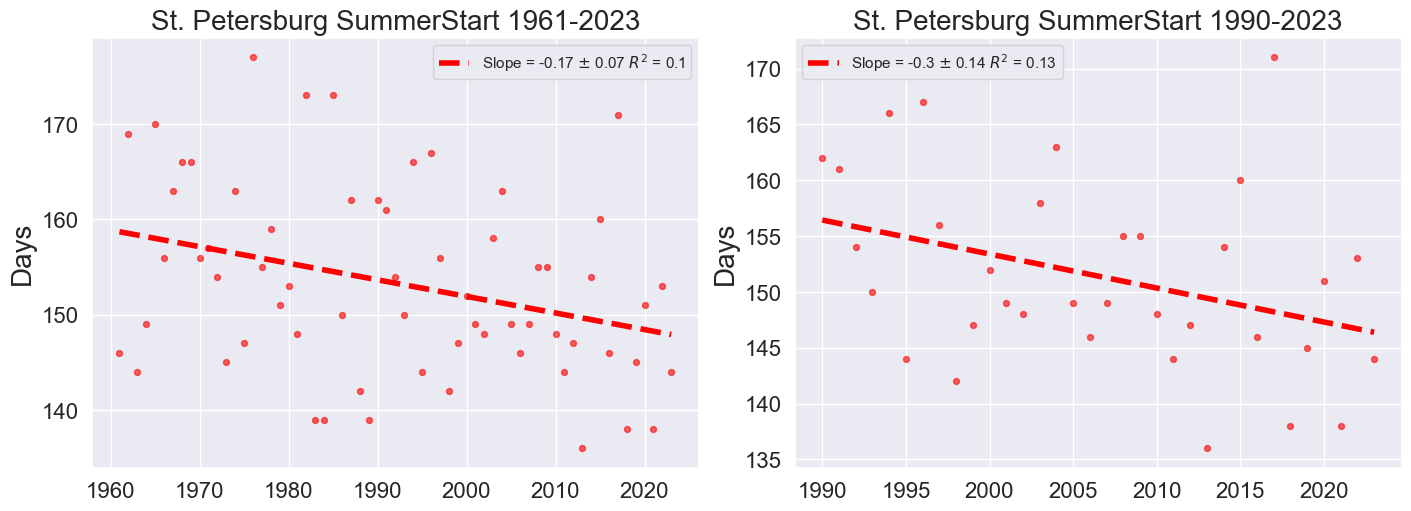

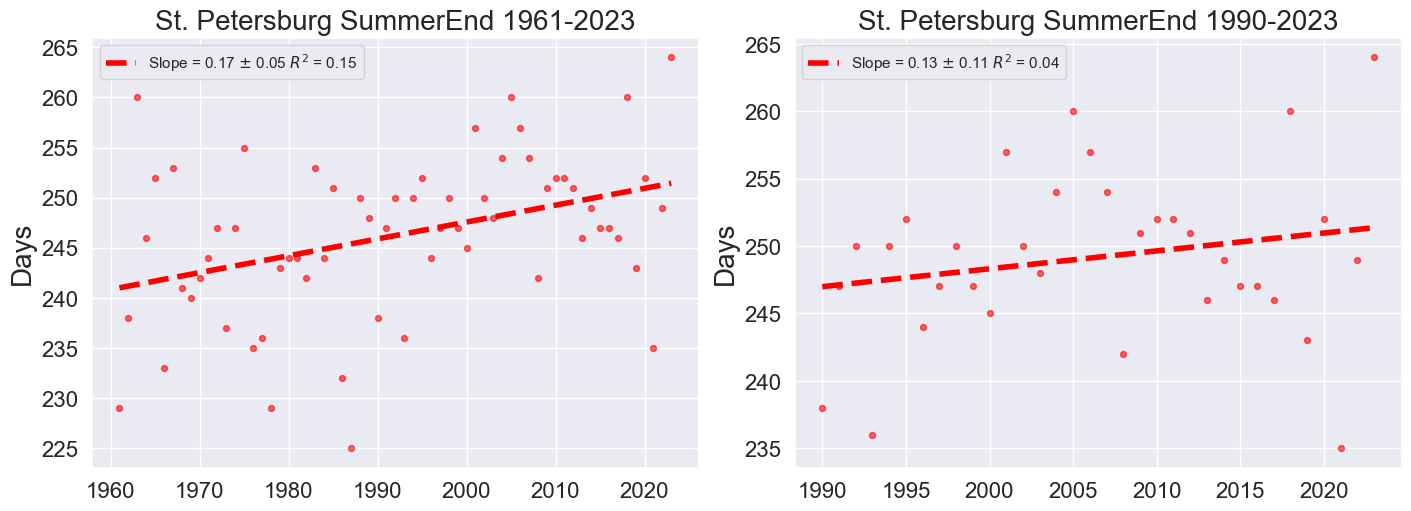

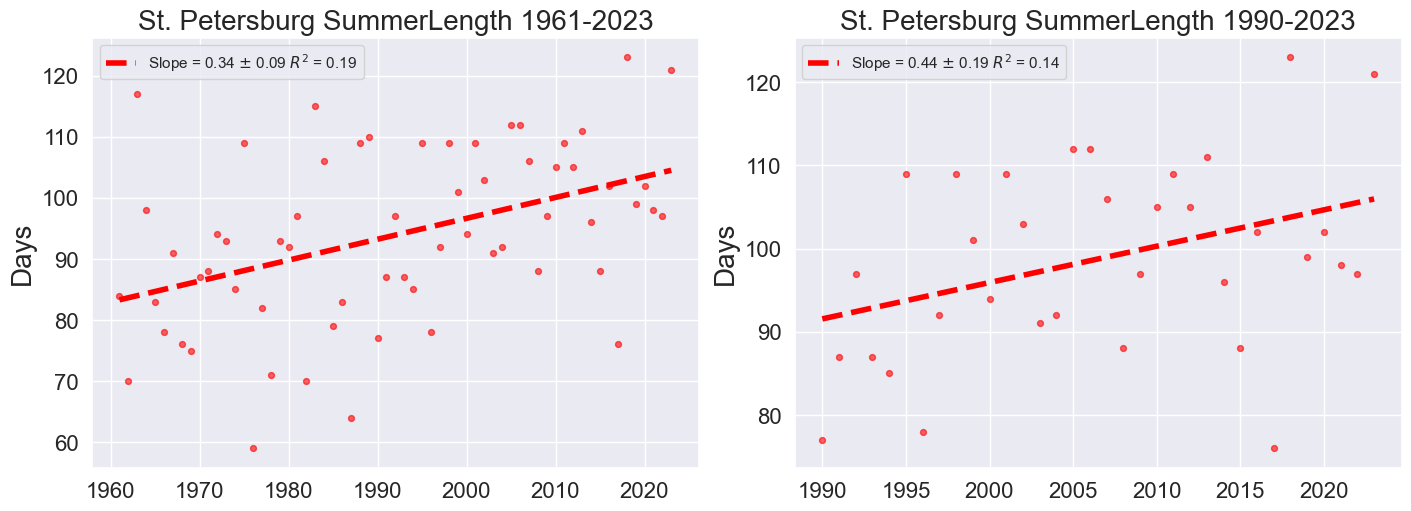

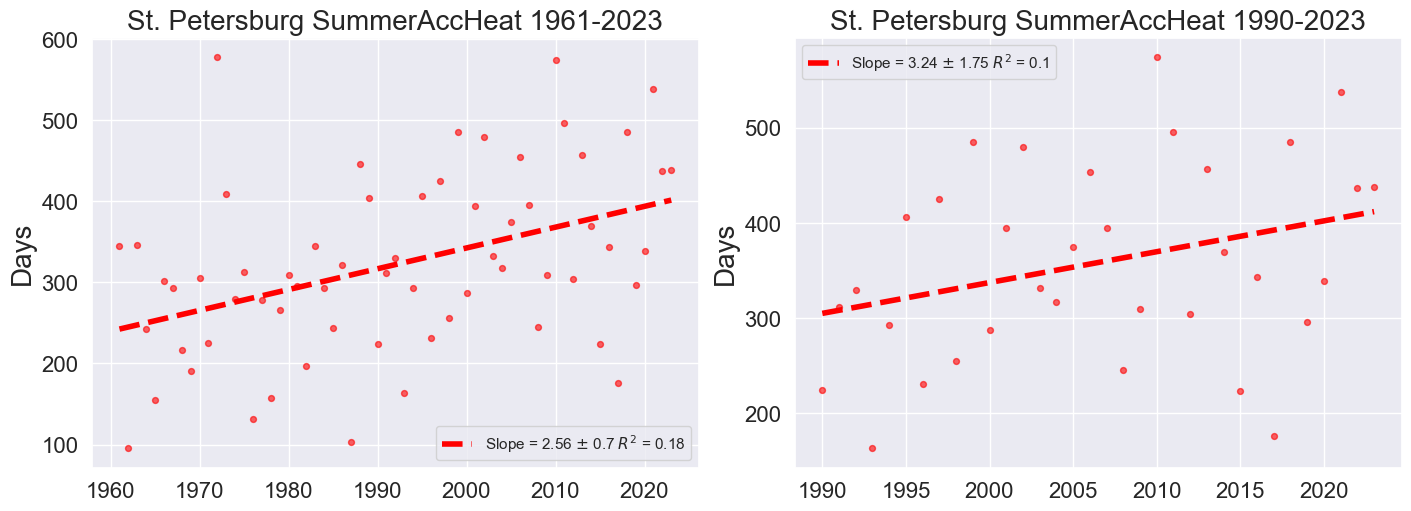

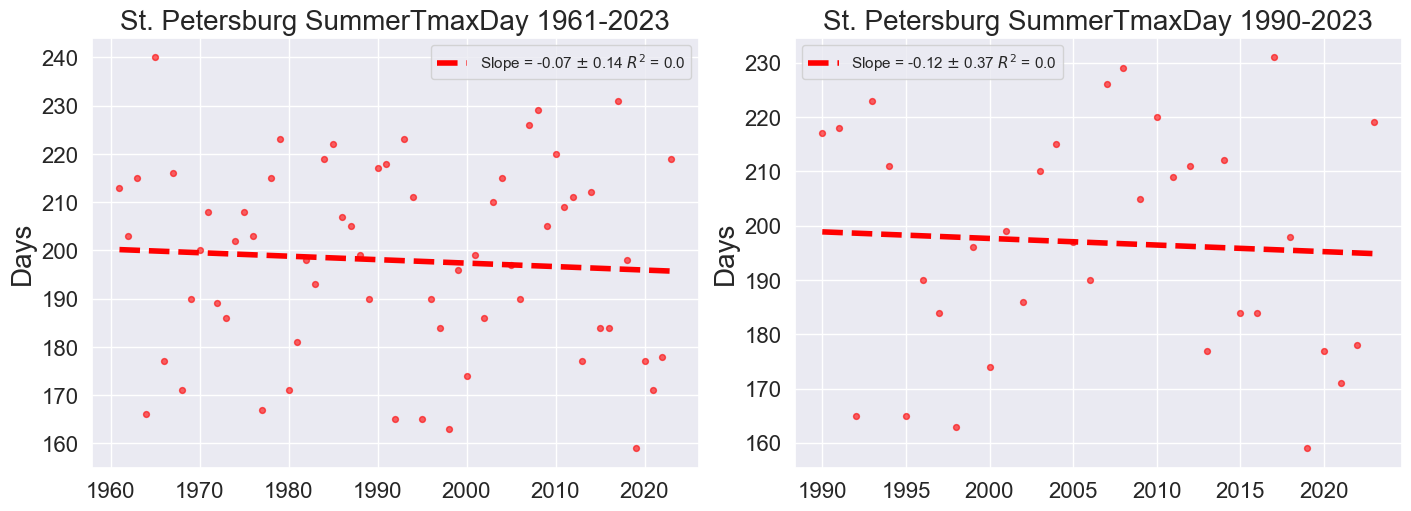

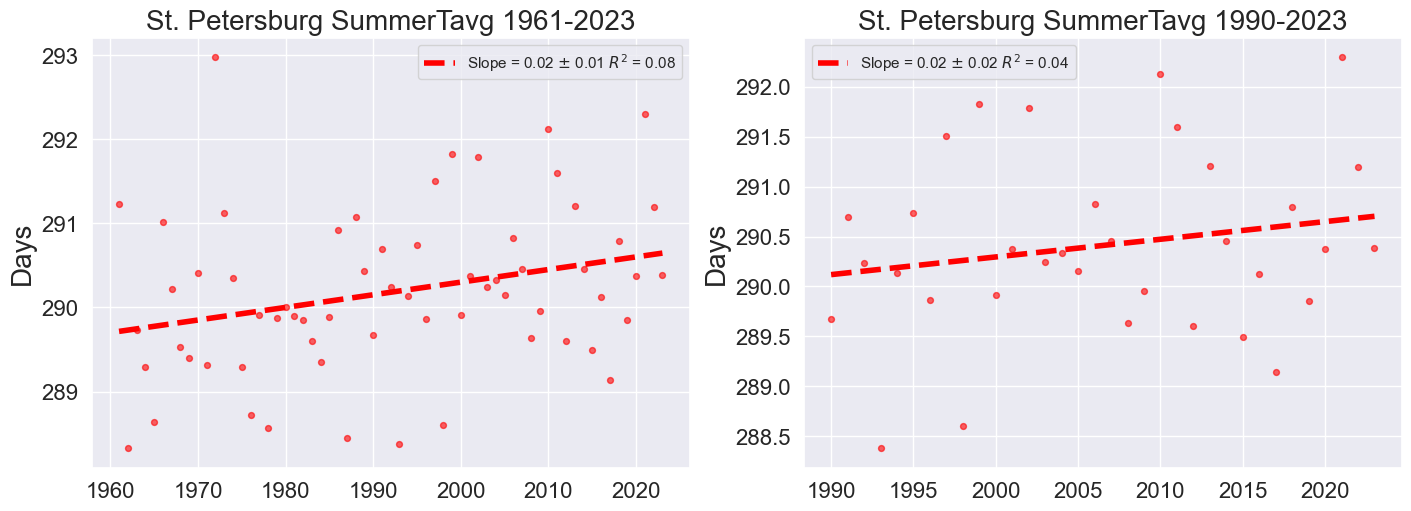

In [201]:
# plot properties so I can more easily tweak them
s = 18
lw = 4
alpha = 0.6
fs = 20
sns.set_theme(style="darkgrid")


# loop through all plot variables
for i,v in enumerate(plot_vars):


    # variables for plot
    x = df_summ.Year
    y = df_summ[v]
    
    # get linear fit and plot it with data
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = np.round(coefs[0],2)
    slope_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    # plot data for full period
    fig = plt.figure(figsize=(14,5), layout='constrained')
    
    ax1 = fig.add_subplot(1,2,1)
    ax1.scatter(x, y, label="", c="red", s=s, alpha=alpha)
    ax1.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='red', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
    ax1.set_title("St. Petersburg "+v+" 1961-2023", fontsize=fs)
    ax1.legend(loc="best")
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    ax1.set_ylabel('Days', fontsize=fs)
    
    
    # analysis period 1990-2023
    # variables for plot
    x = df_summ.Year[df_summ.Year >= 1990]
    y = df_summ[v][df_summ.Year >= 1990]
    
    # get linear fit and plot it with data
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = np.round(coefs[0],2)
    slope_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    ax2 = fig.add_subplot(1,2,2)
    ax2.scatter(x, y, label="", c="red", s=s, alpha=alpha)
    ax2.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='red', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
    ax2.set_title("St. Petersburg "+v+" 1990-2023", fontsize=fs)
    ax2.legend(loc="best")
    ax2.tick_params('x', labelsize=16)
    ax2.tick_params('y', labelsize=16)
    ax2.set_ylabel('Days', fontsize=fs)
    


## **New York (LaGuardia Airport)** has complete data

### https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USW00014732/detail

In [203]:
df = pd.read_csv("../../../Data/GHCND/new_york_laguardia_airport-2025-04-07T17-49-38.csv")
df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN
0,USW00014732,NaN,NaN,NaN,NaN,1961-01-01,NaN,6.7,1.1
1,USW00014732,NaN,NaN,NaN,NaN,1961-01-02,NaN,3.9,-1.7
2,USW00014732,NaN,NaN,NaN,NaN,1961-01-03,NaN,1.7,-0.6
3,USW00014732,NaN,NaN,NaN,NaN,1961-01-04,NaN,0.0,-5.0
4,USW00014732,NaN,NaN,NaN,NaN,1961-01-05,NaN,1.1,-6.1
...,...,...,...,...,...,...,...,...,...
23005,USW00014732,NaN,NaN,NaN,NaN,2023-12-27,6.7,8.9,6.1
23006,USW00014732,NaN,NaN,NaN,NaN,2023-12-28,9.5,11.1,8.3
23007,USW00014732,NaN,NaN,NaN,NaN,2023-12-29,9.8,13.3,7.8
23008,USW00014732,NaN,NaN,NaN,NaN,2023-12-30,7.2,8.3,4.4


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23010 entries, 0 to 23009
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   STATION    23010 non-null  object 
 1   NAME       0 non-null      float64
 2   LATITUDE   0 non-null      float64
 3   LONGITUDE  0 non-null      float64
 4   ELEVATION  0 non-null      float64
 5   DATE       23010 non-null  object 
 6   TAVG       6600 non-null   float64
 7   TMAX       23010 non-null  float64
 8   TMIN       23010 non-null  float64
dtypes: float64(7), object(2)
memory usage: 1.6+ MB


In [205]:
df['TAVG'].to_list()[:5]

[nan, nan, nan, nan, nan]

In [210]:
# 40.77945°, -73.88027°
df['LATITUDE'] = 40.77945
df['LONGITUDE'] = -73.88027


### for this site TAVG must be calc from TMAX and TMIN if TAVG is empty

In [211]:
# can either use a lambda or fillna per https://datascience.stackexchange.com/questions/17769/how-to-fill-missing-value-based-on-other-columns-in-pandas-dataframe
df['TAVG'] = df['TAVG'].fillna((df['TMAX'] + df['TMIN'])/2.0)
df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN
0,USW00014732,NaN,40.77945,-73.88027,NaN,1961-01-01,3.90,6.7,1.1
1,USW00014732,NaN,40.77945,-73.88027,NaN,1961-01-02,1.10,3.9,-1.7
2,USW00014732,NaN,40.77945,-73.88027,NaN,1961-01-03,0.55,1.7,-0.6
3,USW00014732,NaN,40.77945,-73.88027,NaN,1961-01-04,-2.50,0.0,-5.0
4,USW00014732,NaN,40.77945,-73.88027,NaN,1961-01-05,-2.50,1.1,-6.1
...,...,...,...,...,...,...,...,...,...
23005,USW00014732,NaN,40.77945,-73.88027,NaN,2023-12-27,6.70,8.9,6.1
23006,USW00014732,NaN,40.77945,-73.88027,NaN,2023-12-28,9.50,11.1,8.3
23007,USW00014732,NaN,40.77945,-73.88027,NaN,2023-12-29,9.80,13.3,7.8
23008,USW00014732,NaN,40.77945,-73.88027,NaN,2023-12-30,7.20,8.3,4.4


In [212]:
df['DATE'] = pd.to_datetime(df['DATE'])
df_sub = pd.DataFrame({'time':df['DATE'],
                      #'lat':df['LATITUDE'],
                      #'lon':df['LONGITUDE'],
                      'tavg':df['TAVG'].to_list()})
df_sub = df_sub.set_index(['time'])#,'lat','lon'])

# convert to Kelvin
df_sub['tavg'] = df_sub['tavg'] + 273.15
df_sub

,tavg
time,
1961-01-01,277.05
1961-01-02,274.25
1961-01-03,273.70
1961-01-04,270.65
1961-01-05,270.65
...,...
2023-12-27,279.85
2023-12-28,282.65
2023-12-29,282.95


### Convert from Pandas to XArray

In [213]:
da_stp = df_sub.to_xarray()
da_stp.tavg.attrs['units'] = "Degrees [K]"
da_stp.tavg.attrs['long_name'] = "Mean temperature"
da_stp

<xarray.Dataset> Size: 368kB
Dimensions:  (time: 23010)
Coordinates:
  * time     (time) datetime64[ns] 184kB 1961-01-01 1961-01-02 ... 2023-12-31
Data variables:
    tavg     (time) float64 184kB 277.0 274.2 273.7 270.6 ... 282.9 280.3 278.5

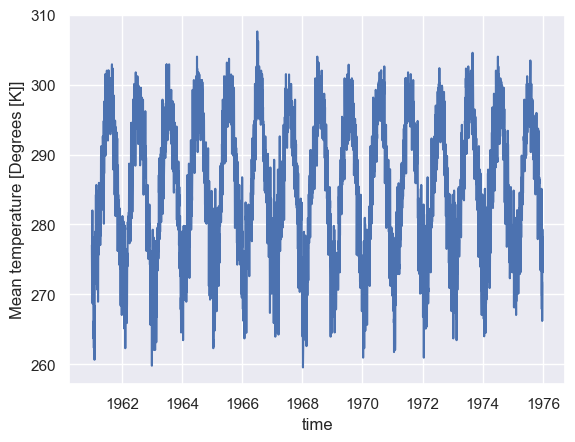

In [214]:
da_stp.tavg.sel(time=slice('1961','1975')).plot()

### Calculate the threshold temp from 1961-1990, 75%-ile

In [215]:
# get threshold for this location
thresh = c_75.sel(lat=df.LATITUDE[0], lon=df.LONGITUDE[0], method="nearest")
print(thresh)

<xarray.DataArray 't2m' ()> Size: 8B
array(293.660675)
Coordinates:
    lat       float64 8B 40.75
    lon       float64 8B -74.0
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K


####  Calculate it from the observational data instead for comparison

In [216]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
stp_75 = da_stp.tavg.quantile(0.75, dim=('time'))
stp_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
stp_75.attrs["units"] = "K"
stp_75

CPU times: user 2.83 ms, sys: 2.58 ms, total: 5.41 ms
Wall time: 4.36 ms


<xarray.DataArray 'tavg' ()> Size: 8B
array(294.8)
Coordinates:
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

In [217]:
thresh.values - stp_75.values

np.float64(-1.1393249511718295)

#### New York LaGuardia 75th Percentile from GHCND data is 1.14 K warmer

### Try one year (2023) fit via Fourier

In [218]:
da.tavg.values[0]

np.float64(274.75)

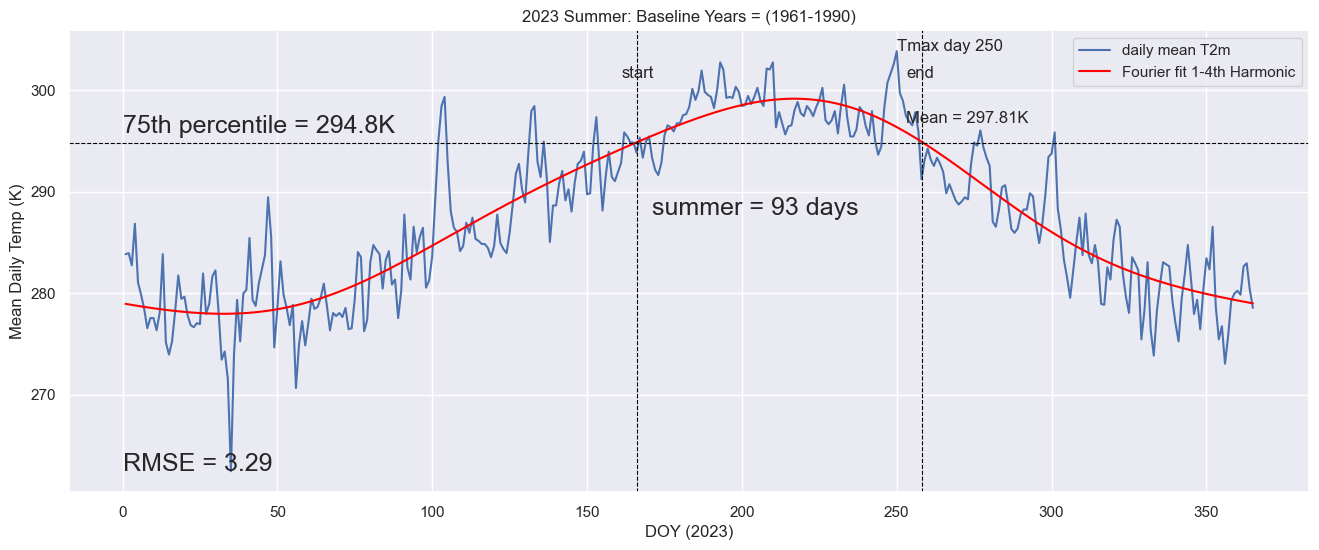

(166,
 258,
 250,
 297.09999999999854,
 93,
 3.2910892063515713,
 0.0,
 297.808064516129,
 3.5369047619047365)

In [219]:
input_year = 2023
da = da_stp.sel(time=str(input_year))
# since this is in the NH don't really need a next year
da_next = da_stp.sel(time=str(input_year))
da = HandleLeapYears(da)
da_next = HandleLeapYears(da_next)

curr = da.tavg
nxt = da_next.tavg
thresh = stp_75
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

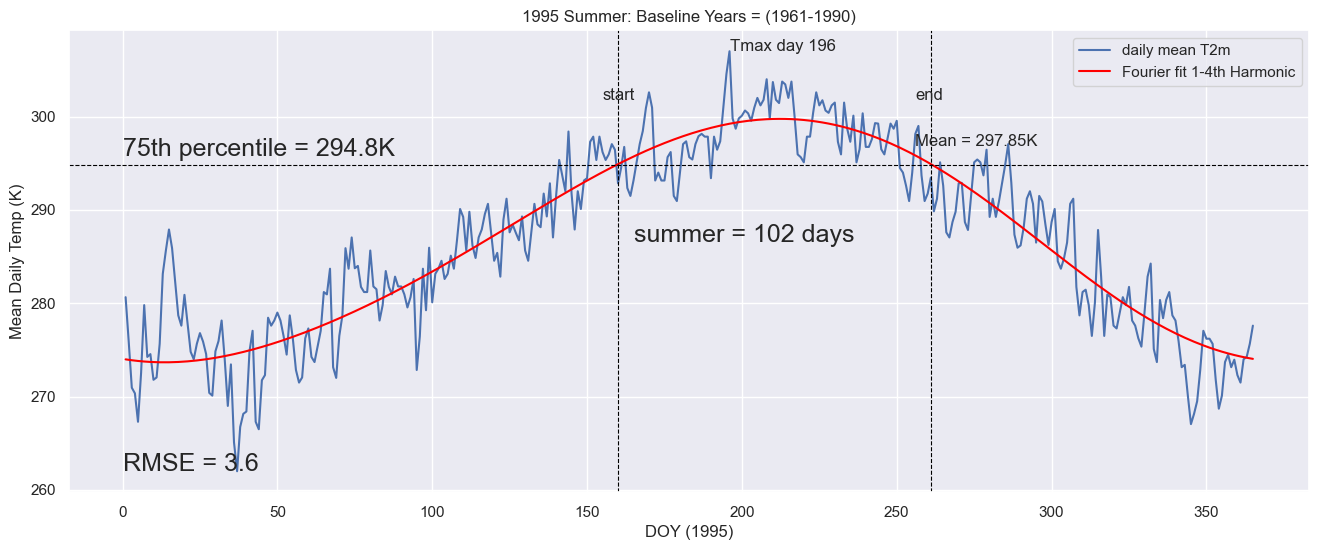

(160,
 261,
 196,
 355.8999999999978,
 102,
 3.5965572986437655,
 0.0,
 297.8475490196078,
 4.448749999999961)

In [220]:
# how about 1995
input_year = 1995
da = da_stp.sel(time=str(input_year))
# since this is in the NH don't really need a next year
da_next = da_stp.sel(time=str(input_year))
da = HandleLeapYears(da)
da_next = HandleLeapYears(da_next)

curr = da.tavg
nxt = da_next.tavg
thresh = stp_75
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

### Looks to be working!

### Run through all years now and then uuse ideas from "AnalyzeTrends" script to output the 1961-2023 summer stats aggregated file for analysis

### Main Loop: loop through multiple years to generate summer stats

In [223]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1961, 2024,1)

process_yrs

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [224]:
%%time

# Runtime: XX min for 1 year
# XXX for 10 years
# XXX for 64 years

# empty dataframe for the results
df_summ = pd.DataFrame({"Year":[],
                        "SummerStart":[],
                        "SummerEnd":[],
                        "SummerLength":[],
                        "SummerAccHeat":[],
                        "SummerTmaxDay":[],
                        "SummerTavg":[]})#.set_index(["Year"])


# loop thru the years in the defined array above
for input_year in process_yrs:

    da = da_stp.sel(time=str(input_year))
    # since this is in the NH don't really need a next year
    da_next = da_stp.sel(time=str(input_year))
    da = HandleLeapYears(da)
    da_next = HandleLeapYears(da_next)
    
    curr = da.tavg
    nxt = da_next.tavg
    thresh = stp_75
    start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, False, True, True, True)

    #print(start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs)
    #### Build up a dataframe of the values for later plotting ####
    df_tmp = pd.DataFrame({"Year":[(input_year)],
                        "SummerStart":[(start_day)],
                        "SummerEnd":[(last_day)],
                        "SummerLength":[(summer_length)],
                        "SummerAccHeat":[(acc_heat)],
                        "SummerTmaxDay":[(day_of_max)],
                        "SummerTavg":[(mean_temp)]
                          })#.set_index(["Year"])
    df_summ = pd.concat([df_summ, df_tmp], ignore_index=True)


# output results
df_summ[["Year","SummerStart","SummerEnd","SummerLength","SummerTmaxDay"]] = df_summ[["Year","SummerStart","SummerEnd","SummerLength","SummerTmaxDay"]].astype(int)
df_summ



CPU times: user 286 ms, sys: 10.7 ms, total: 296 ms
Wall time: 300 ms


,Year,SummerStart,SummerEnd,SummerLength,SummerAccHeat,SummerTmaxDay,SummerTavg
0,1961,171,261,91,257.20,245,297.128571
1,1962,157,234,78,137.35,169,295.992949
2,1963,169,239,71,176.25,178,296.953521
3,1964,160,244,85,207.30,182,296.884118
4,1965,156,251,96,263.10,206,297.075521
...,...,...,...,...,...,...,...
58,2019,160,259,100,344.85,202,297.941000
59,2020,160,256,97,428.15,208,299.122165
60,2021,159,266,108,355.20,181,297.871296
61,2022,162,255,94,366.75,201,298.554255


### write out resulting summer stats

In [225]:
# write out results
output_path = "../../../Data/GHCND/new_york_summer_stats.csv"
df_summ.to_csv(output_path)

### New York: Plot the summer stats

In [226]:
plot_vars = ["SummerStart","SummerEnd","SummerLength","SummerAccHeat","SummerTmaxDay","SummerTavg"]

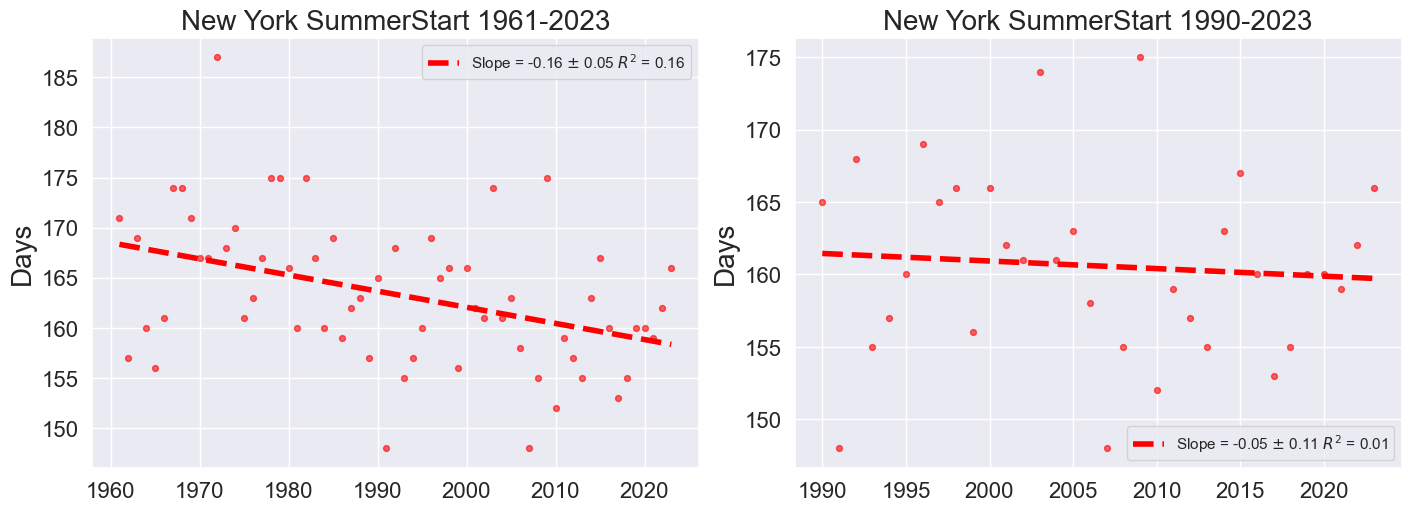

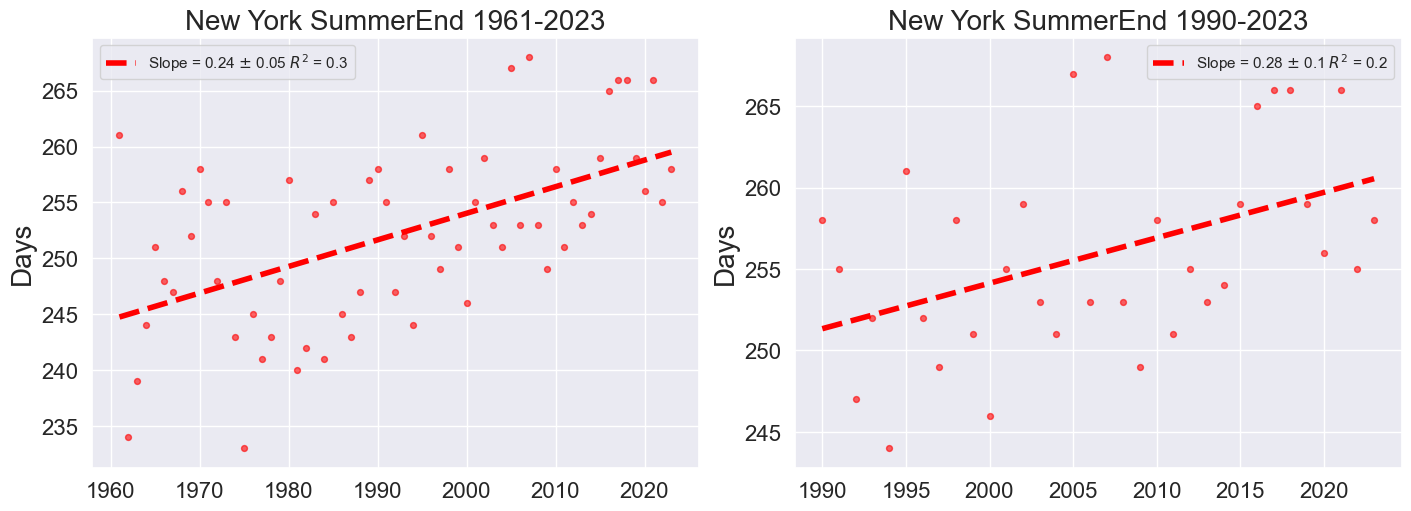

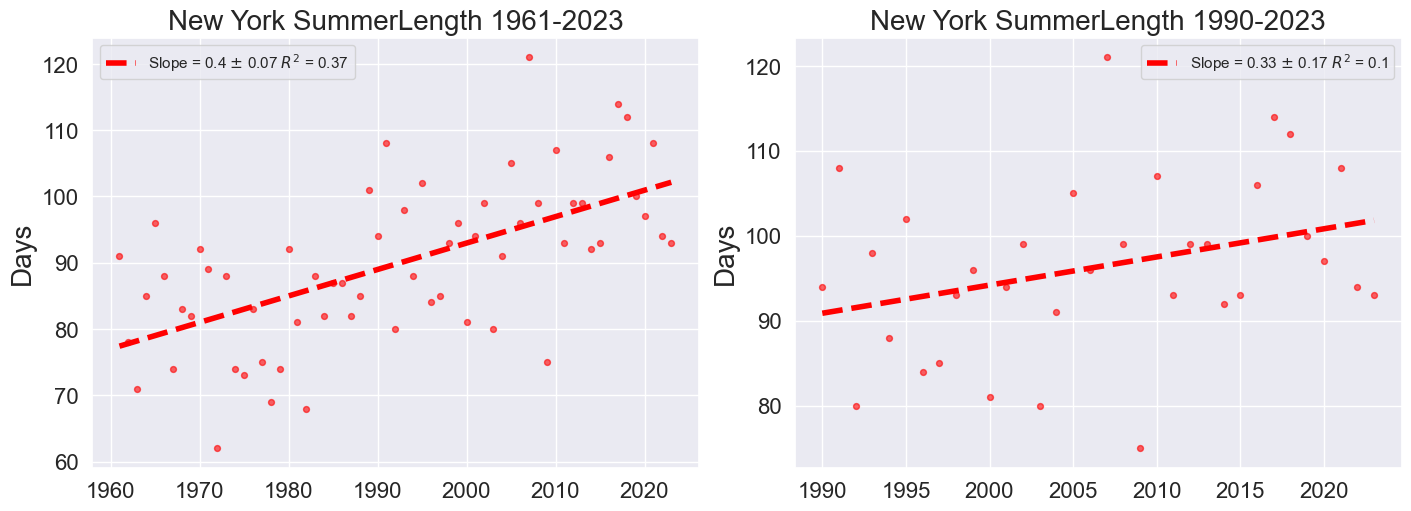

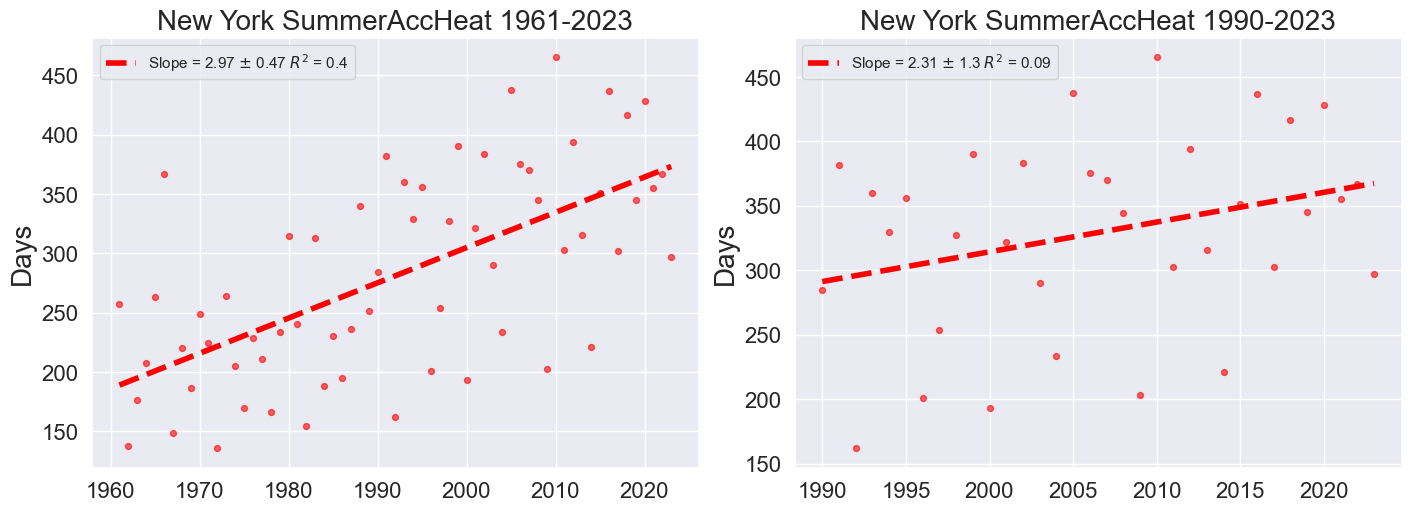

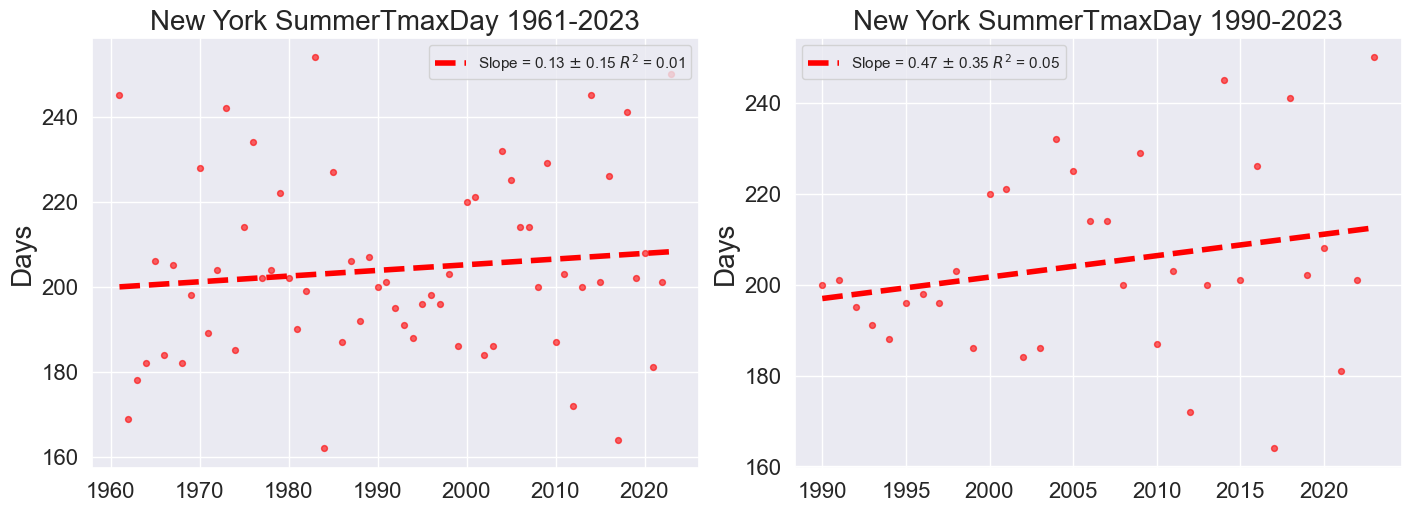

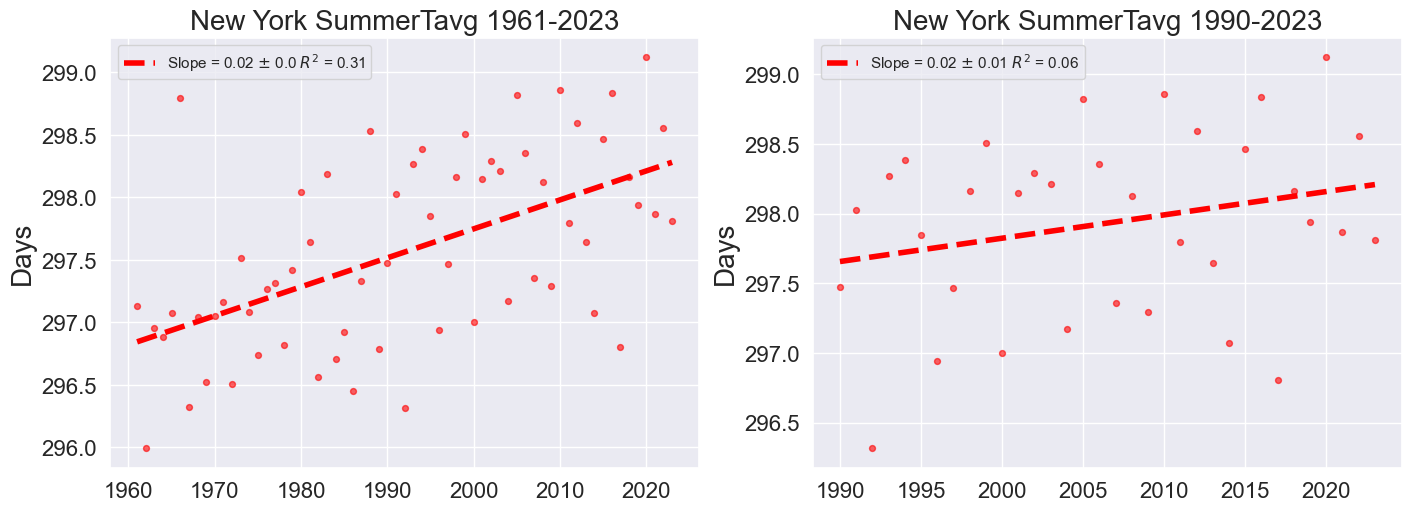

In [227]:
# plot properties so I can more easily tweak them
s = 18
lw = 4
alpha = 0.6
fs = 20
sns.set_theme(style="darkgrid")


# loop through all plot variables
for i,v in enumerate(plot_vars):


    # variables for plot
    x = df_summ.Year
    y = df_summ[v]
    
    # get linear fit and plot it with data
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = np.round(coefs[0],2)
    slope_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    # plot data for full period
    fig = plt.figure(figsize=(14,5), layout='constrained')
    
    ax1 = fig.add_subplot(1,2,1)
    ax1.scatter(x, y, label="", c="red", s=s, alpha=alpha)
    ax1.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='red', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
    ax1.set_title("New York "+v+" 1961-2023", fontsize=fs)
    ax1.legend(loc="best")
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    ax1.set_ylabel('Days', fontsize=fs)
    
    
    # analysis period 1990-2023
    # variables for plot
    x = df_summ.Year[df_summ.Year >= 1990]
    y = df_summ[v][df_summ.Year >= 1990]
    
    # get linear fit and plot it with data
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = np.round(coefs[0],2)
    slope_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    ax2 = fig.add_subplot(1,2,2)
    ax2.scatter(x, y, label="", c="red", s=s, alpha=alpha)
    ax2.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='red', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
    ax2.set_title("New York "+v+" 1990-2023", fontsize=fs)
    ax2.legend(loc="best")
    ax2.tick_params('x', labelsize=16)
    ax2.tick_params('y', labelsize=16)
    ax2.set_ylabel('Days', fontsize=fs)
    


## **Cordoba, Argentina (Airport)** has complete data

### https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:AR000087344/detail

### This is in the SH so we need 2024

In [228]:
df = pd.read_csv("../../../Data/GHCND/cordoba_argentina-2025-04-08T18-09-00.csv")
df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN
0,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,1961-01-01,NaN,NaN,16.4
1,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,1961-01-02,NaN,NaN,18.4
2,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,1961-01-03,NaN,NaN,12.6
3,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,1961-01-04,NaN,NaN,10.4
4,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,1961-01-05,NaN,NaN,14.4
...,...,...,...,...,...,...,...,...,...
23359,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,2024-12-27,22.1,NaN,11.4
23360,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,2024-12-28,22.8,31.0,16.1
23361,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,2024-12-29,23.2,NaN,15.7
23362,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,2024-12-30,23.3,NaN,15.3


### for this site TAVG must be calc from TMAX and TMIN if TAVG is empty

In [230]:
# can either use a lambda or fillna per https://datascience.stackexchange.com/questions/17769/how-to-fill-missing-value-based-on-other-columns-in-pandas-dataframe
df['TAVG'] = df['TAVG'].fillna((df['TMAX'] + df['TMIN'])/2.0)
df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN
0,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,1961-01-01,NaN,NaN,16.4
1,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,1961-01-02,NaN,NaN,18.4
2,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,1961-01-03,NaN,NaN,12.6
3,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,1961-01-04,NaN,NaN,10.4
4,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,1961-01-05,NaN,NaN,14.4
...,...,...,...,...,...,...,...,...,...
23359,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,2024-12-27,22.1,NaN,11.4
23360,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,2024-12-28,22.8,31.0,16.1
23361,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,2024-12-29,23.2,NaN,15.7
23362,AR000087344,"CORDOBA AERO, AR",-31.317,-64.217,489.0,2024-12-30,23.3,NaN,15.3


#### Still some empty TAVG during 1961 but we have enough I think

In [259]:
df['DATE'] = pd.to_datetime(df['DATE'])
df_sub = pd.DataFrame({'time':df['DATE'],
                      #'lat':df['LATITUDE'],
                      #'lon':df['LONGITUDE'],
                      'tavg':df['TAVG'].to_list()})
df_sub = df_sub.set_index(['time'])#,'lat','lon'])

# convert to Kelvin
df_sub['tavg'] = df_sub['tavg'] + 273.15
df_sub

,tavg
time,
1961-01-01,NaN
1961-01-02,NaN
1961-01-03,NaN
1961-01-04,NaN
1961-01-05,NaN
...,...
2024-12-27,295.25
2024-12-28,295.95
2024-12-29,296.35


In [284]:
#pd.set_option('display.max_rows', 500)
df_sub['tavg'].tail(357)


time
2024-01-01    296.05
2024-01-02    296.65
2024-01-03    297.85
2024-01-04    298.45
2024-01-05    298.55
               ...  
2024-12-27    295.25
2024-12-28    295.95
2024-12-29    296.35
2024-12-30    296.45
2024-12-31    298.05
Name: tavg, Length: 357, dtype: float64

In [283]:
pd.reset_option('display.max_rows')

#### The following 9 rows are missing from 2024: 3/28-3/31, 11/18-11/21, 12/1

#### Will fill them in with NaN and then use linear interpolation to fill them in since FFT can't work with missing data

In [300]:
df_missing = pd.DataFrame({'time':pd.to_datetime(['2024-03-28','2024-03-29','2024-03-30','2024-03-31','2024-11-18','2024-11-19','2024-11-20','2024-11-21','2024-12-01']),
                           'tavg':np.repeat(np.nan, 9)})
df_missing = df_missing.set_index(['time'])
df_missing
                                                 

,tavg
time,
2024-03-28,NaN
2024-03-29,NaN
2024-03-30,NaN
2024-03-31,NaN
2024-11-18,NaN
2024-11-19,NaN
2024-11-20,NaN
2024-11-21,NaN
2024-12-01,NaN


In [305]:
df_sub = pd.concat([df_sub, df_missing], axis=0).sort_index()
df_sub

,tavg
time,
1961-01-01,NaN
1961-01-02,NaN
1961-01-03,NaN
1961-01-04,NaN
1961-01-05,NaN
...,...
2024-12-27,295.25
2024-12-28,295.95
2024-12-29,296.35


In [324]:
# linear interpolation
df_sub['tavg'] = df_sub['tavg'].interpolate(method='linear')
df_sub.head(10),df_sub.tail(40)

(            tavg
 time            
 1961-01-01   NaN
 1961-01-02   NaN
 1961-01-03   NaN
 1961-01-04   NaN
 1961-01-05   NaN
 1961-01-06   NaN
 1961-01-07   NaN
 1961-01-08   NaN
 1961-01-09   NaN
 1961-01-10   NaN,
               tavg
 time              
 2024-11-22  295.55
 2024-11-23  296.55
 2024-11-24  300.35
 2024-11-25  295.25
 2024-11-26  296.55
 2024-11-27  295.05
 2024-11-28  295.15
 2024-11-29  289.55
 2024-11-30  289.85
 2024-12-01  290.35
 2024-12-02  290.85
 2024-12-03  287.85
 2024-12-04  294.25
 2024-12-05  298.25
 2024-12-06  297.15
 2024-12-07  291.65
 2024-12-08  289.45
 2024-12-09  291.85
 2024-12-10  295.75
 2024-12-11  296.75
 2024-12-12  299.35
 2024-12-13  293.85
 2024-12-14  296.35
 2024-12-15  295.95
 2024-12-16  295.35
 2024-12-17  295.95
 2024-12-18  292.75
 2024-12-19  294.25
 2024-12-20  296.95
 2024-12-21  291.75
 2024-12-22  292.95
 2024-12-23  296.85
 2024-12-24  294.95
 2024-12-25  293.85
 2024-12-26  293.45
 2024-12-27  295.25
 2024-12-28  295.95
 20

In [325]:
df1 = df_sub[df_sub.isna().any(axis=1)]
print(df1)

            tavg
time            
1961-01-01   NaN
1961-01-02   NaN
1961-01-03   NaN
1961-01-04   NaN
1961-01-05   NaN
...          ...
1961-05-27   NaN
1961-05-28   NaN
1961-05-29   NaN
1961-05-30   NaN
1961-05-31   NaN

[150 rows x 1 columns]


#### 1961 can't be fixed by interpolation but since this is in the SH and the "year" doesn't start until June 30 in my analysis, we can still get the summer of 1961 (I think)

### Convert from Pandas to XArray

In [326]:
da_stp = df_sub.to_xarray()
da_stp.tavg.attrs['units'] = "Degrees [K]"
da_stp.tavg.attrs['long_name'] = "Mean temperature"
da_stp

<xarray.Dataset> Size: 374kB
Dimensions:  (time: 23373)
Coordinates:
  * time     (time) datetime64[ns] 187kB 1961-01-01 1961-01-02 ... 2024-12-31
Data variables:
    tavg     (time) float64 187kB nan nan nan nan ... 295.9 296.3 296.4 298.0

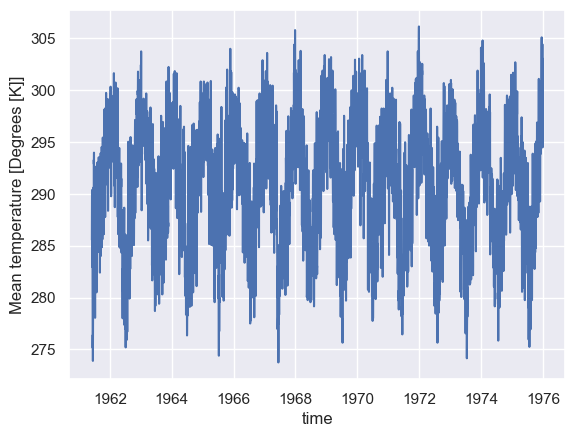

In [327]:
da_stp.tavg.sel(time=slice('1961','1975')).plot()

### Calculate the threshold temp from 1961-1990, 75%-ile

In [328]:
# get threshold for this location
thresh = c_75.sel(lat=df.LATITUDE[0], lon=df.LONGITUDE[0], method="nearest")
print(thresh)

<xarray.DataArray 't2m' ()> Size: 8B
array(293.82132)
Coordinates:
    lat       float64 8B -31.25
    lon       float64 8B -64.25
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K


####  Calculate it from the observational data instead for comparison

In [329]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
stp_75 = da_stp.tavg.quantile(0.75, dim=('time'))
stp_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
stp_75.attrs["units"] = "K"
stp_75

CPU times: user 3.33 ms, sys: 1.73 ms, total: 5.05 ms
Wall time: 3.57 ms


<xarray.DataArray 'tavg' ()> Size: 8B
array(294.95)
Coordinates:
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

In [330]:
thresh.values - stp_75.values

np.float64(-1.1286804199218636)

#### Cordoba, Argentina 75th Percentile from GHCND data is 1.13 K warmer

### Try one year (2023) fit via Fourier

In [331]:
da.tavg.values[0]

np.float64(300.75)

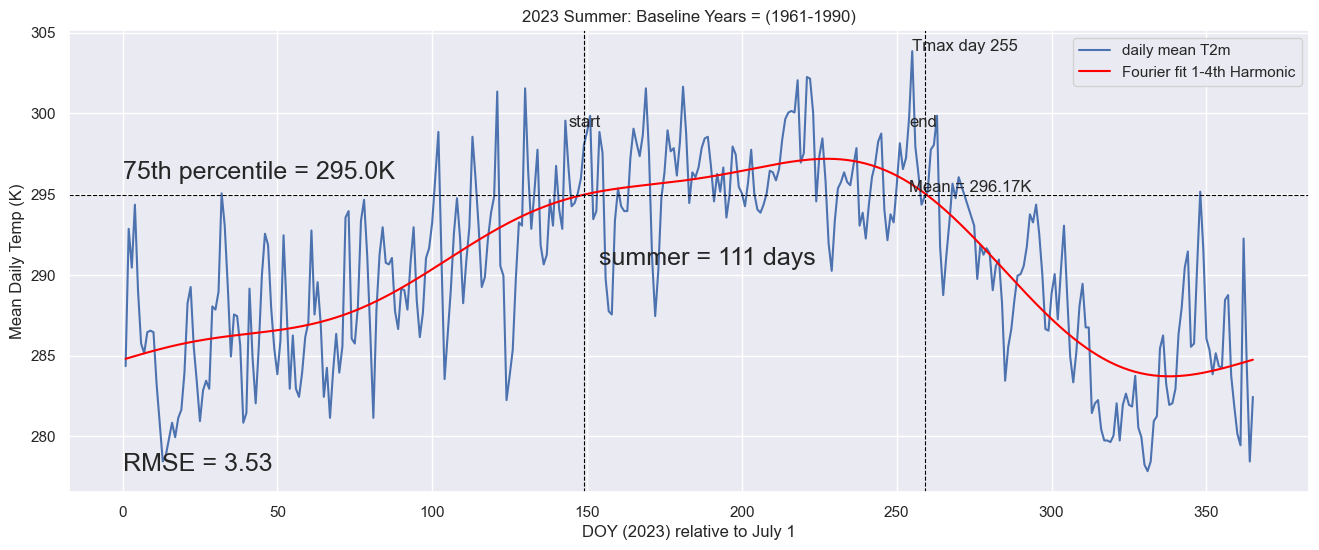

(149,
 259,
 255,
 207.40000000000146,
 111,
 3.5303382803271712,
 0.0,
 296.17162162162157,
 2.6935064935065043)

In [333]:
input_year = 2023
da = da_stp.sel(time=str(input_year))
# since this is in the SH we DO need a next year
da_next = da_stp.sel(time=str(input_year+1))
da = HandleLeapYears(da)
da_next = HandleLeapYears(da_next)

curr = da.tavg
nxt = da_next.tavg
thresh = stp_75
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True, False)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

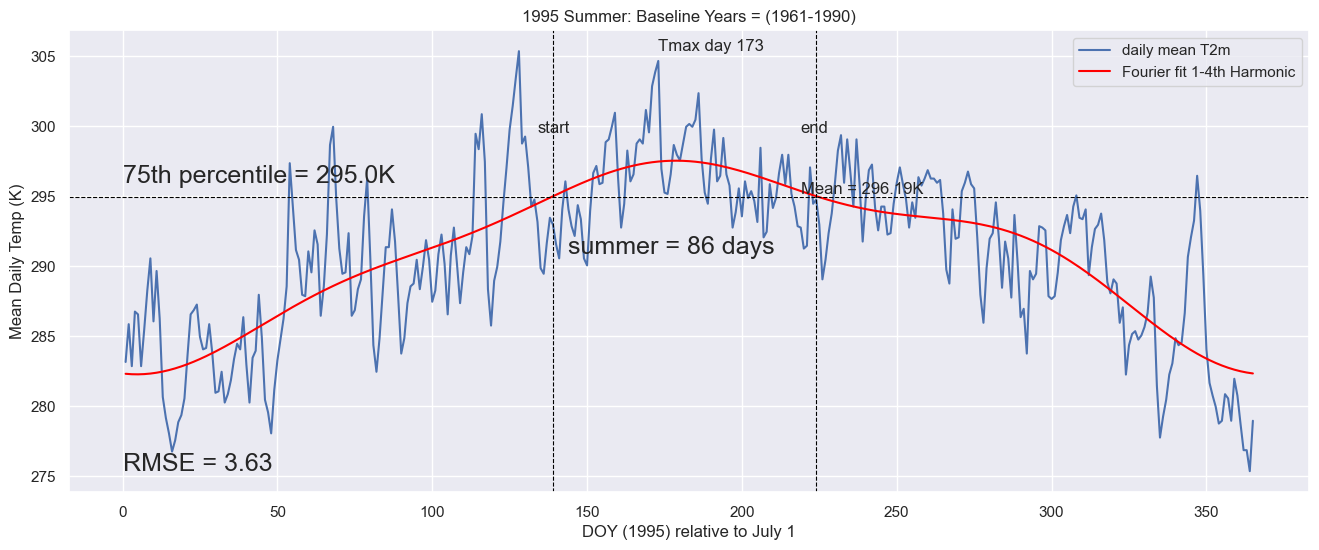

(139,
 224,
 173,
 164.70000000000073,
 86,
 3.6252351204901916,
 0.0,
 296.1872093023256,
 3.0500000000000114)

In [334]:
# how about 1995
input_year = 1995
da = da_stp.sel(time=str(input_year))
# since this is in the NH don't really need a next year
da_next = da_stp.sel(time=str(input_year+1))
da = HandleLeapYears(da)
da_next = HandleLeapYears(da_next)

curr = da.tavg
nxt = da_next.tavg
thresh = stp_75
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True, False)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

### Run through all years now and then uuse ideas from "AnalyzeTrends" script to output the 1961-2023 summer stats aggregated file for analysis

### Main Loop: loop through multiple years to generate summer stats

In [335]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1961, 2024,1)

process_yrs

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [336]:
%%time

# Runtime: XX min for 1 year
# XXX for 10 years
# XXX for 64 years

# empty dataframe for the results
df_summ = pd.DataFrame({"Year":[],
                        "SummerStart":[],
                        "SummerEnd":[],
                        "SummerLength":[],
                        "SummerAccHeat":[],
                        "SummerTmaxDay":[],
                        "SummerTavg":[]})#.set_index(["Year"])


# loop thru the years in the defined array above
for input_year in process_yrs:

    da = da_stp.sel(time=str(input_year))
    # since this is in the SH we need a next year
    da_next = da_stp.sel(time=str(input_year+1))
    da = HandleLeapYears(da)
    da_next = HandleLeapYears(da_next)
    
    curr = da.tavg
    nxt = da_next.tavg
    thresh = stp_75
    start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, False, True, True, False)

    #print(start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs)
    #### Build up a dataframe of the values for later plotting ####
    df_tmp = pd.DataFrame({"Year":[(input_year)],
                        "SummerStart":[(start_day)],
                        "SummerEnd":[(last_day)],
                        "SummerLength":[(summer_length)],
                        "SummerAccHeat":[(acc_heat)],
                        "SummerTmaxDay":[(day_of_max)],
                        "SummerTavg":[(mean_temp)]
                          })#.set_index(["Year"])
    df_summ = pd.concat([df_summ, df_tmp], ignore_index=True)


# output results
df_summ[["Year","SummerStart","SummerEnd","SummerLength","SummerTmaxDay"]] = df_summ[["Year","SummerStart","SummerEnd","SummerLength","SummerTmaxDay"]].astype(int)
df_summ



CPU times: user 339 ms, sys: 10.7 ms, total: 350 ms
Wall time: 370 ms


,Year,SummerStart,SummerEnd,SummerLength,SummerAccHeat,SummerTmaxDay,SummerTavg
0,1961,153,259,107,132.300,231,295.419159
1,1962,142,233,92,174.850,188,296.392935
2,1963,171,235,65,97.650,220,295.805385
3,1964,172,253,82,149.325,198,296.271646
4,1965,150,228,79,110.000,151,295.478481
...,...,...,...,...,...,...,...
58,2019,140,242,103,162.950,164,295.902913
59,2020,149,217,69,82.900,163,295.287681
60,2021,145,230,86,214.500,198,296.776744
61,2022,137,263,127,336.900,160,297.105906


### write out resulting summer stats

In [337]:
# write out results
output_path = "../../../Data/GHCND/cordoba_summer_stats.csv"
df_summ.to_csv(output_path)

### Cordoba: Plot the summer stats

In [338]:
plot_vars = ["SummerStart","SummerEnd","SummerLength","SummerAccHeat","SummerTmaxDay","SummerTavg"]

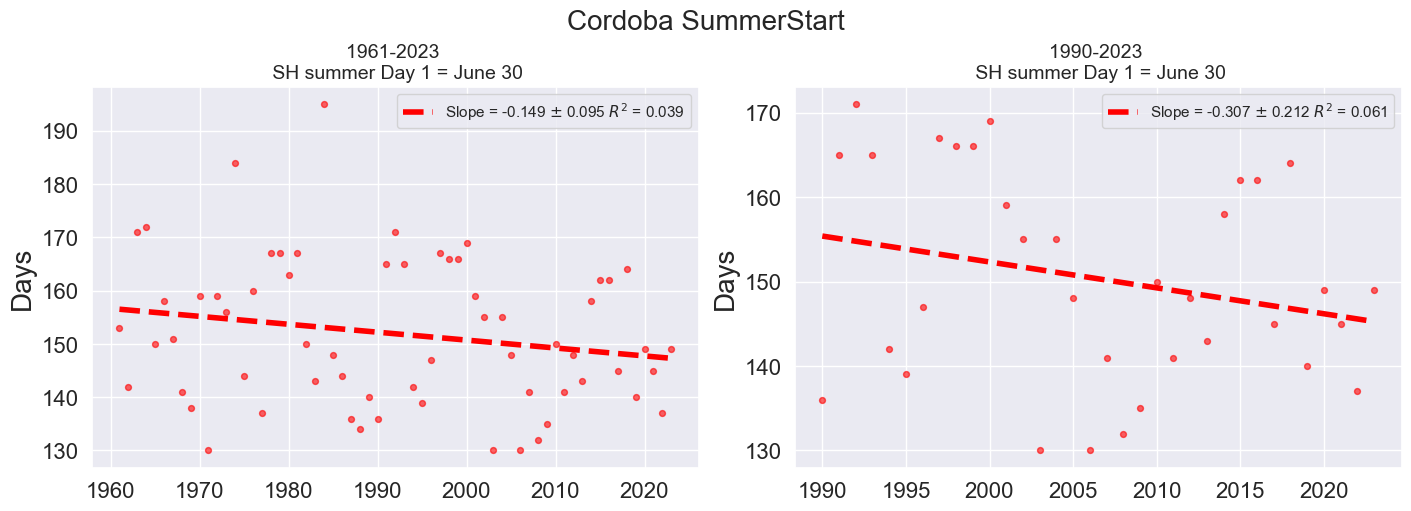

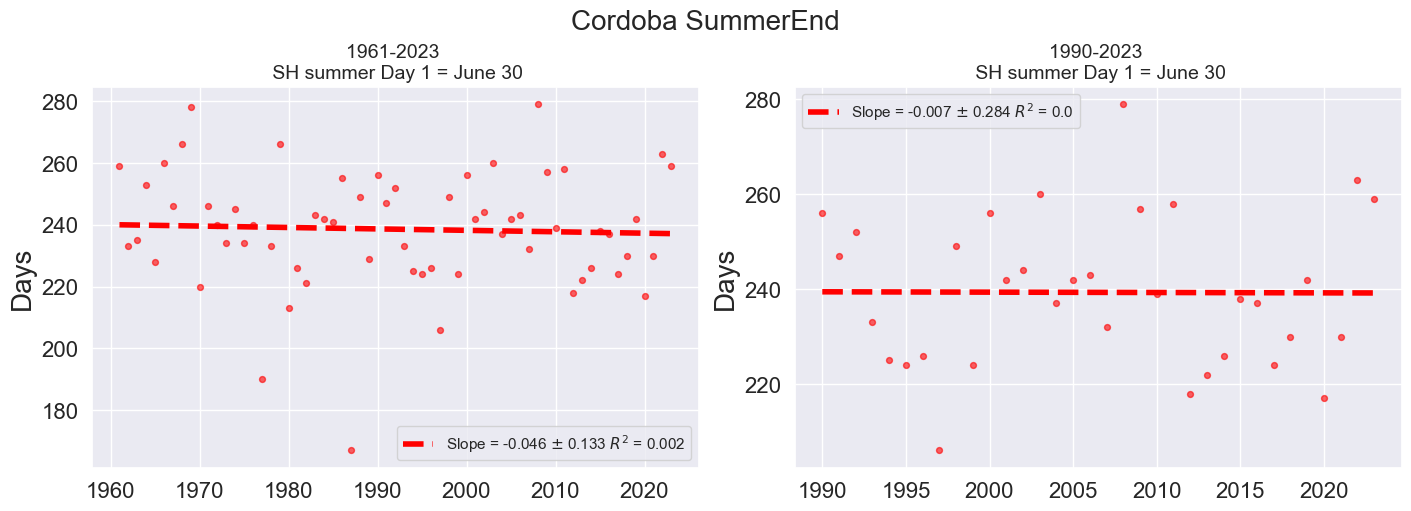

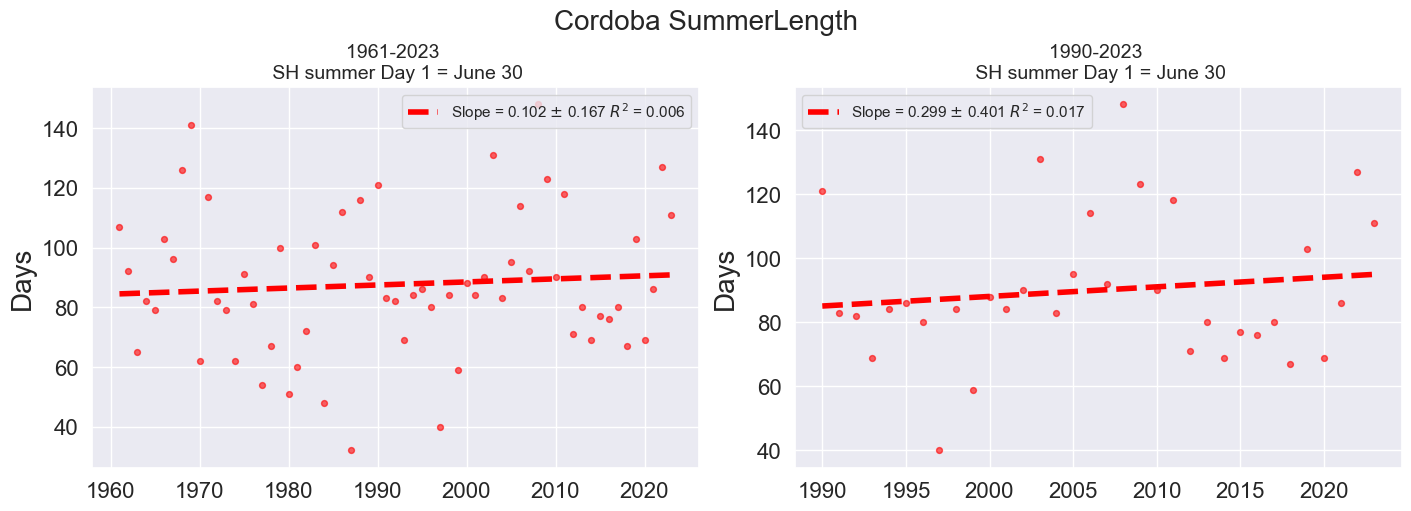

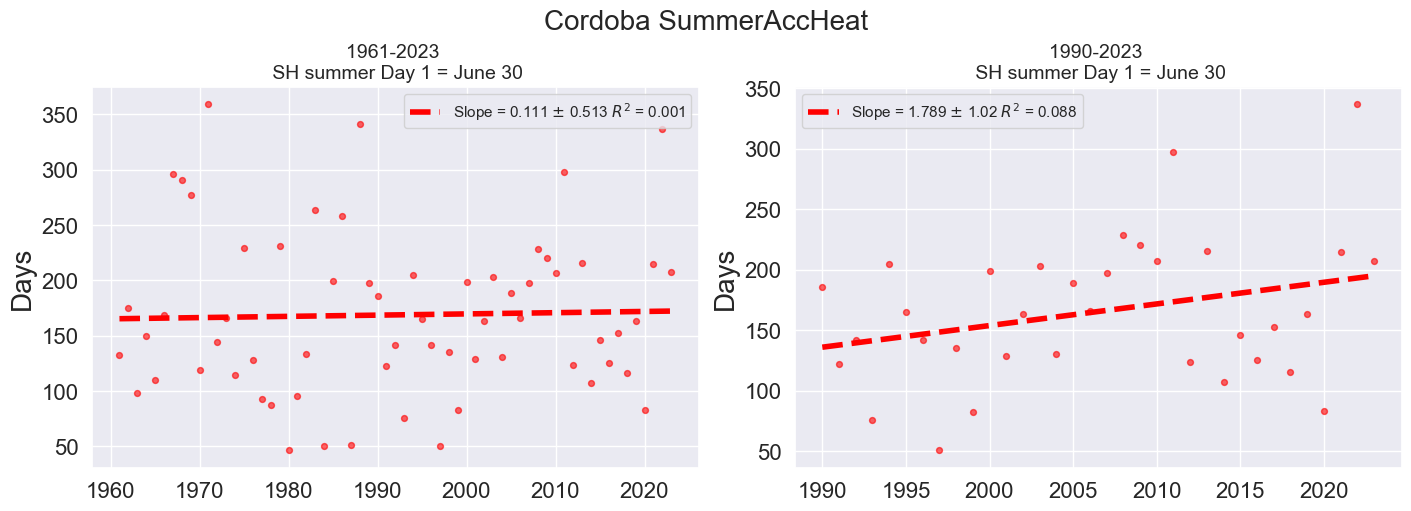

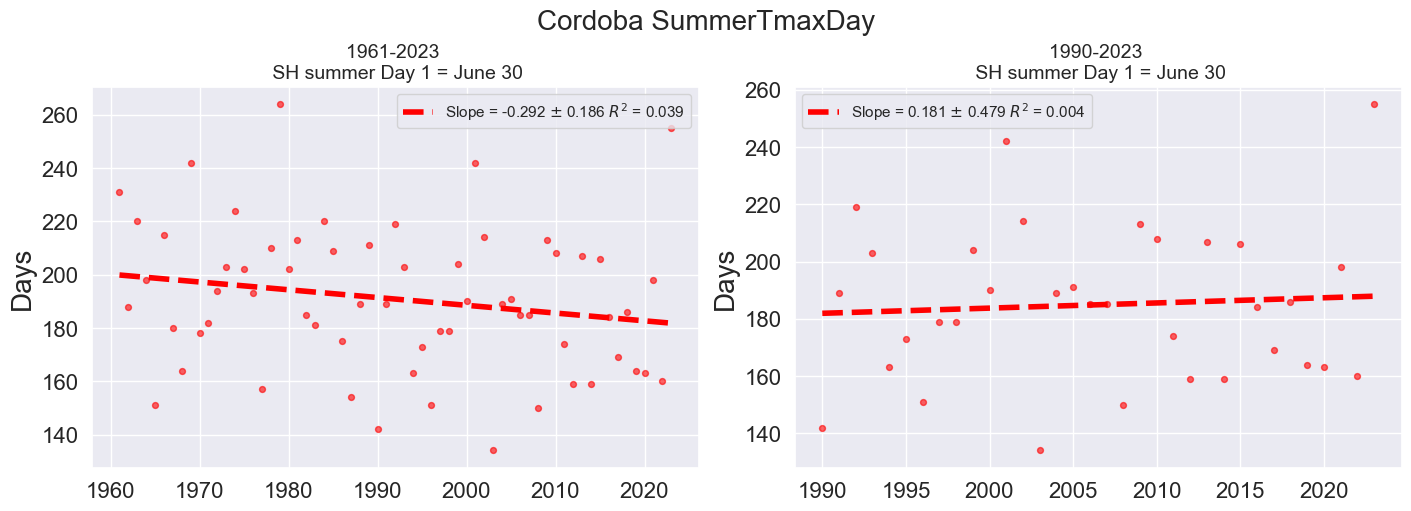

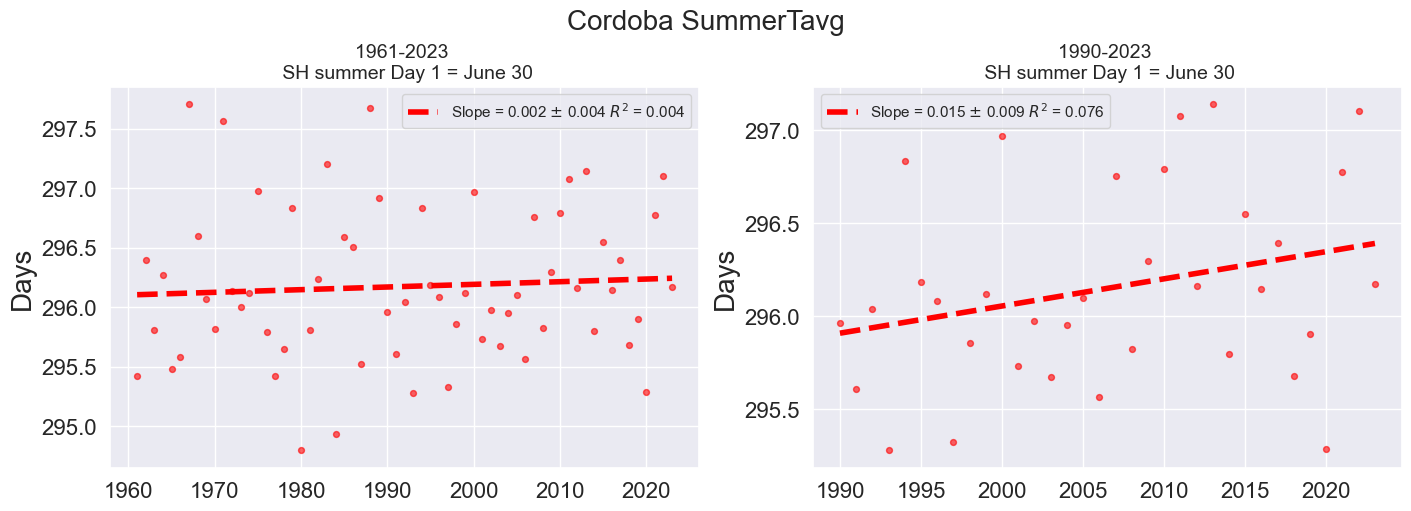

In [342]:
# plot properties so I can more easily tweak them
s = 18
lw = 4
alpha = 0.6
fs = 20
sns.set_theme(style="darkgrid")


# loop through all plot variables
for i,v in enumerate(plot_vars):


    # variables for plot
    x = df_summ.Year
    y = df_summ[v]
    
    # get linear fit and plot it with data
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = np.round(coefs[0],3)
    slope_sd = np.round(np.sqrt(V[0][0]),3)  
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),3)
    
    # plot data for full period
    fig = plt.figure(figsize=(14,5), layout='constrained')
    
    ax1 = fig.add_subplot(1,2,1)
    ax1.scatter(x, y, label="", c="red", s=s, alpha=alpha)
    ax1.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='red', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
    plt.suptitle("Cordoba "+v, fontsize=fs)
    #ax1.set_title("Cordoba "+v+" 1961-2023", fontsize=fs)
    ax1.set_title("1961-2023 \n SH summer Day 1 = June 30", fontsize=14)
    ax1.legend(loc="best")
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    ax1.set_ylabel('Days', fontsize=fs)
    
    
    # analysis period 1990-2023
    # variables for plot
    x = df_summ.Year[df_summ.Year >= 1990]
    y = df_summ[v][df_summ.Year >= 1990]
    
    # get linear fit and plot it with data
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = np.round(coefs[0],3)
    slope_sd = np.round(np.sqrt(V[0][0]),3)  
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),3)
    
    ax2 = fig.add_subplot(1,2,2)
    ax2.scatter(x, y, label="", c="red", s=s, alpha=alpha)
    ax2.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='red', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
    ax2.set_title("1990-2023 \n SH summer Day 1 = June 30", fontsize=14)
    ax2.legend(loc="best")
    ax2.tick_params('x', labelsize=16)
    ax2.tick_params('y', labelsize=16)
    ax2.set_ylabel('Days', fontsize=fs)
    


### Cordoba isn't the best candidate given the very narrow range of temps and nearly flat slopes for the metrics - will have to find another SH inland site?

## **Paris, Orly ** has complete data

### https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:FRM00007149/detail

In [343]:
df = pd.read_csv("../../../Data/GHCND/paris_orly-2025-04-07T18-03-51.csv")
df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN
0,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,1961-01-01,NaN,5.0,-1.2
1,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,1961-01-02,NaN,10.3,2.3
2,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,1961-01-03,NaN,7.3,2.5
3,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,1961-01-04,NaN,7.3,2.3
4,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,1961-01-05,NaN,6.9,1.1
...,...,...,...,...,...,...,...,...,...
23005,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,2023-12-27,9.4,11.1,7.5
23006,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,2023-12-28,10.0,11.0,9.1
23007,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,2023-12-29,10.2,11.3,8.8
23008,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,2023-12-30,9.3,11.5,6.8


In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23010 entries, 0 to 23009
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   STATION    23010 non-null  object 
 1   NAME       23010 non-null  object 
 2   LATITUDE   23010 non-null  float64
 3   LONGITUDE  23010 non-null  float64
 4   ELEVATION  23010 non-null  float64
 5   DATE       23010 non-null  object 
 6   TAVG       18213 non-null  float64
 7   TMAX       23010 non-null  float64
 8   TMIN       23010 non-null  float64
dtypes: float64(6), object(3)
memory usage: 1.6+ MB


### for this site TAVG must be calc from TMAX and TMIN if TAVG is empty

In [345]:
# can either use a lambda or fillna per https://datascience.stackexchange.com/questions/17769/how-to-fill-missing-value-based-on-other-columns-in-pandas-dataframe
df['TAVG'] = df['TAVG'].fillna((df['TMAX'] + df['TMIN'])/2.0)
df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN
0,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,1961-01-01,1.9,5.0,-1.2
1,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,1961-01-02,6.3,10.3,2.3
2,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,1961-01-03,4.9,7.3,2.5
3,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,1961-01-04,4.8,7.3,2.3
4,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,1961-01-05,4.0,6.9,1.1
...,...,...,...,...,...,...,...,...,...
23005,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,2023-12-27,9.4,11.1,7.5
23006,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,2023-12-28,10.0,11.0,9.1
23007,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,2023-12-29,10.2,11.3,8.8
23008,FRM00007149,"ORLY, FR",48.7167,2.3842,89.0,2023-12-30,9.3,11.5,6.8


In [346]:
# check counts again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23010 entries, 0 to 23009
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   STATION    23010 non-null  object 
 1   NAME       23010 non-null  object 
 2   LATITUDE   23010 non-null  float64
 3   LONGITUDE  23010 non-null  float64
 4   ELEVATION  23010 non-null  float64
 5   DATE       23010 non-null  object 
 6   TAVG       23010 non-null  float64
 7   TMAX       23010 non-null  float64
 8   TMIN       23010 non-null  float64
dtypes: float64(6), object(3)
memory usage: 1.6+ MB


In [347]:
df['DATE'] = pd.to_datetime(df['DATE'])
df_sub = pd.DataFrame({'time':df['DATE'],
                      #'lat':df['LATITUDE'],
                      #'lon':df['LONGITUDE'],
                      'tavg':df['TAVG'].to_list()})
df_sub = df_sub.set_index(['time'])#,'lat','lon'])

# convert to Kelvin
df_sub['tavg'] = df_sub['tavg'] + 273.15
df_sub

,tavg
time,
1961-01-01,275.05
1961-01-02,279.45
1961-01-03,278.05
1961-01-04,277.95
1961-01-05,277.15
...,...
2023-12-27,282.55
2023-12-28,283.15
2023-12-29,283.35


### Convert from Pandas to XArray

In [348]:
da_stp = df_sub.to_xarray()
da_stp.tavg.attrs['units'] = "Degrees [K]"
da_stp.tavg.attrs['long_name'] = "Mean temperature"
da_stp

<xarray.Dataset> Size: 368kB
Dimensions:  (time: 23010)
Coordinates:
  * time     (time) datetime64[ns] 184kB 1961-01-01 1961-01-02 ... 2023-12-31
Data variables:
    tavg     (time) float64 184kB 275.0 279.4 278.0 277.9 ... 283.3 282.4 282.4

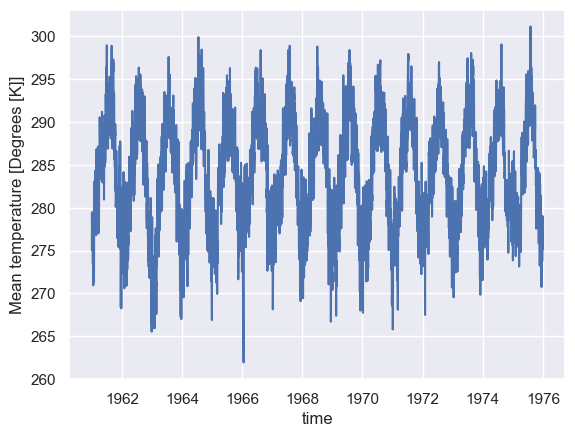

In [349]:
da_stp.tavg.sel(time=slice('1961','1975')).plot()

### Calculate the threshold temp from 1961-1990, 75%-ile

In [350]:
# get threshold for this location
thresh = c_75.sel(lat=df.LATITUDE[0], lon=df.LONGITUDE[0], method="nearest")
print(thresh)

<xarray.DataArray 't2m' ()> Size: 8B
array(288.722626)
Coordinates:
    lat       float64 8B 48.75
    lon       float64 8B 2.5
    quantile  float64 8B ...
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K


####  Calculate it from the observational data instead for comparison

In [351]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
stp_75 = da_stp.tavg.quantile(0.75, dim=('time'))
stp_75.attrs["long_name"] = "75th percentile 2m Temperature for the data across available time dimension"
stp_75.attrs["units"] = "K"
stp_75

CPU times: user 3.66 ms, sys: 2.61 ms, total: 6.28 ms
Wall time: 3.7 ms


<xarray.DataArray 'tavg' ()> Size: 8B
array(289.75)
Coordinates:
    quantile  float64 8B 0.75
Attributes:
    long_name:  75th percentile 2m Temperature for the data across available ...
    units:      K

In [352]:
thresh.values - stp_75.values

np.float64(-1.027374267578125)

#### Paris (Orly) 75th Percentile from GHCND data is 1.02 K warmer

### Try one year (2023) fit via Fourier

In [353]:
da.tavg.values[0]

np.float64(295.34999999999997)

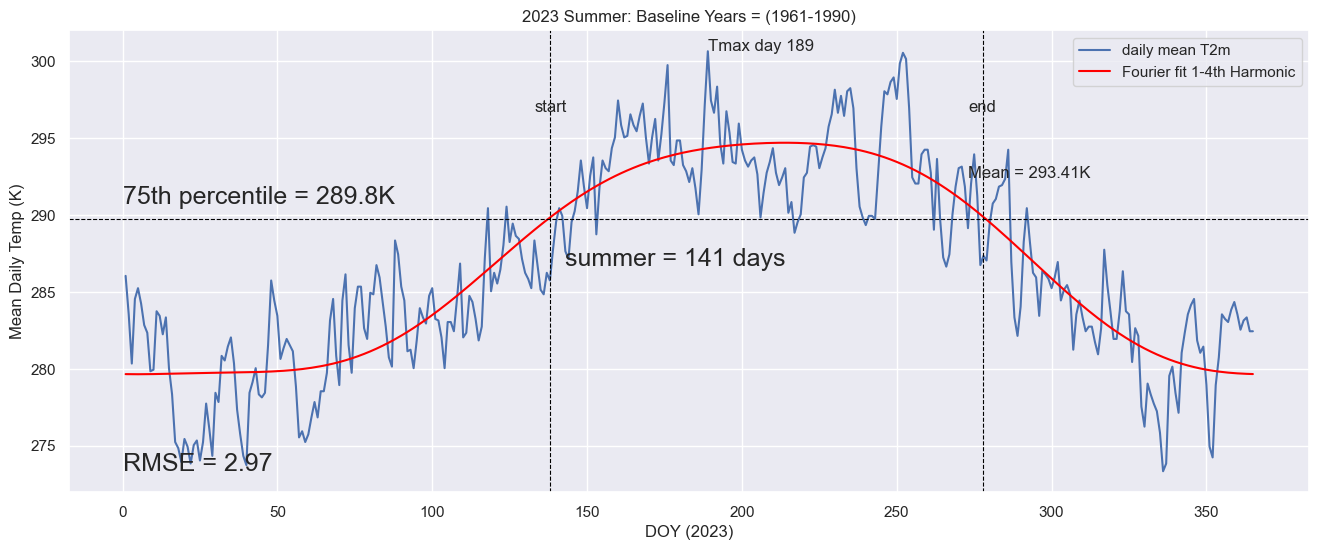

(138,
 278,
 189,
 543.0999999999913,
 141,
 2.968795128479331,
 0.0,
 293.4109929078014,
 4.379838709677358)

In [354]:
input_year = 2023
da = da_stp.sel(time=str(input_year))
# since this is in the NH don't really need a next year
da_next = da_stp.sel(time=str(input_year))
da = HandleLeapYears(da)
da_next = HandleLeapYears(da_next)

curr = da.tavg
nxt = da_next.tavg
thresh = stp_75
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

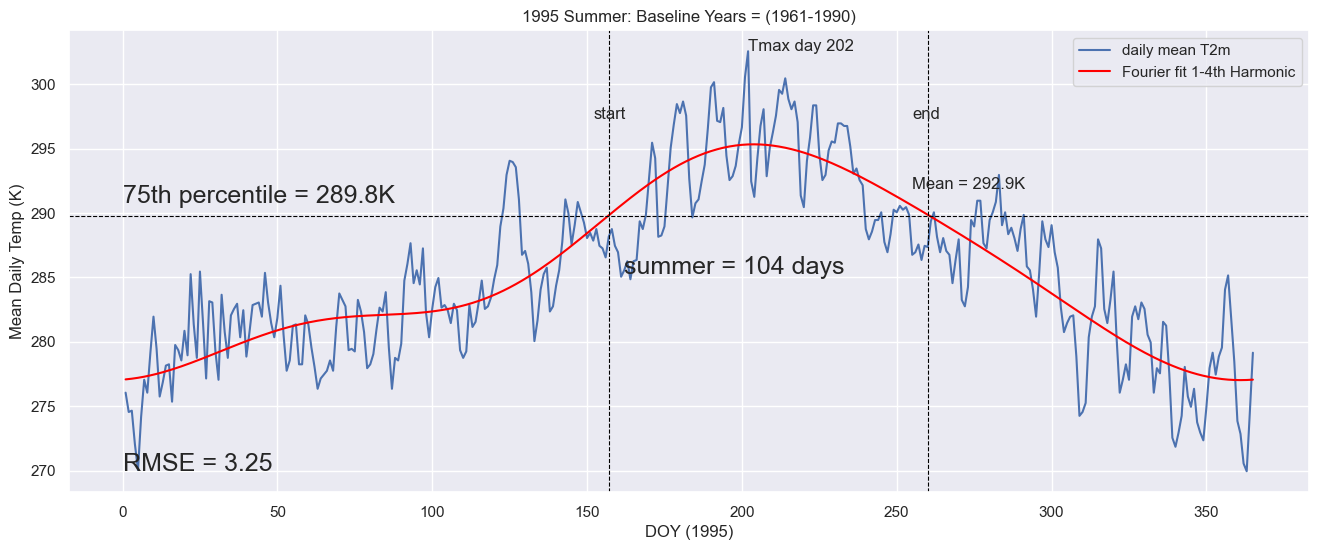

(157,
 260,
 202,
 390.7999999999993,
 104,
 3.2539096801273137,
 0.0,
 292.901923076923,
 5.2810810810810835)

In [355]:
# how about 1995
input_year = 1995
da = da_stp.sel(time=str(input_year))
# since this is in the NH don't really need a next year
da_next = da_stp.sel(time=str(input_year))
da = HandleLeapYears(da)
da_next = HandleLeapYears(da_next)

curr = da.tavg
nxt = da_next.tavg
thresh = stp_75
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, True, True, True, True)
start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs

### Looks to be working!

### Run through all years now and then uuse ideas from "AnalyzeTrends" script to output the 1961-2023 summer stats aggregated file for analysis

### Main Loop: loop through multiple years to generate summer stats

In [356]:
# process_yrs = [1990,1991,1992,1993, 1994, 1995, 1996, 1997, 1998, 1999, 2002, 2004, 2005, 2006, 2007, 2008,
#               2009, 2010, 2011, 2012, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
process_yrs = np.arange(1961, 2024,1)

process_yrs

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [357]:
%%time

# Runtime: XX min for 1 year
# XXX for 10 years
# XXX for 64 years

# empty dataframe for the results
df_summ = pd.DataFrame({"Year":[],
                        "SummerStart":[],
                        "SummerEnd":[],
                        "SummerLength":[],
                        "SummerAccHeat":[],
                        "SummerTmaxDay":[],
                        "SummerTavg":[]})#.set_index(["Year"])


# loop thru the years in the defined array above
for input_year in process_yrs:

    da = da_stp.sel(time=str(input_year))
    # since this is in the NH don't really need a next year
    da_next = da_stp.sel(time=str(input_year))
    da = HandleLeapYears(da)
    da_next = HandleLeapYears(da_next)
    
    curr = da.tavg
    nxt = da_next.tavg
    thresh = stp_75
    start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs = SummerStatsFourier(curr, nxt, thresh, False, True, True, True)

    #print(start_day, last_day, day_of_max, acc_heat, summer_length, rmse, r2, mean_temp, mean_hs)
    #### Build up a dataframe of the values for later plotting ####
    df_tmp = pd.DataFrame({"Year":[(input_year)],
                        "SummerStart":[(start_day)],
                        "SummerEnd":[(last_day)],
                        "SummerLength":[(summer_length)],
                        "SummerAccHeat":[(acc_heat)],
                        "SummerTmaxDay":[(day_of_max)],
                        "SummerTavg":[(mean_temp)]
                          })#.set_index(["Year"])
    df_summ = pd.concat([df_summ, df_tmp], ignore_index=True)


# output results
df_summ[["Year","SummerStart","SummerEnd","SummerLength","SummerTmaxDay"]] = df_summ[["Year","SummerStart","SummerEnd","SummerLength","SummerTmaxDay"]].astype(int)
df_summ



CPU times: user 282 ms, sys: 9.93 ms, total: 292 ms
Wall time: 290 ms


,Year,SummerStart,SummerEnd,SummerLength,SummerAccHeat,SummerTmaxDay,SummerTavg
0,1961,176,268,93,202.55,182,291.660753
1,1962,180,257,78,111.50,206,290.689103
2,1963,170,231,62,94.45,203,290.795161
3,1964,158,256,99,255.20,198,291.898990
4,1965,184,236,53,66.55,217,290.160377
...,...,...,...,...,...,...,...
58,2019,152,262,111,458.10,206,293.587838
59,2020,149,267,119,470.40,221,293.416387
60,2021,152,264,113,338.40,167,292.658850
61,2022,138,270,133,539.10,200,293.401880


### write out resulting summer stats

In [358]:
# write out results
output_path = "../../../Data/GHCND/paris-orly_summer_stats.csv"
df_summ.to_csv(output_path)

### New York: Plot the summer stats

In [359]:
plot_vars = ["SummerStart","SummerEnd","SummerLength","SummerAccHeat","SummerTmaxDay","SummerTavg"]

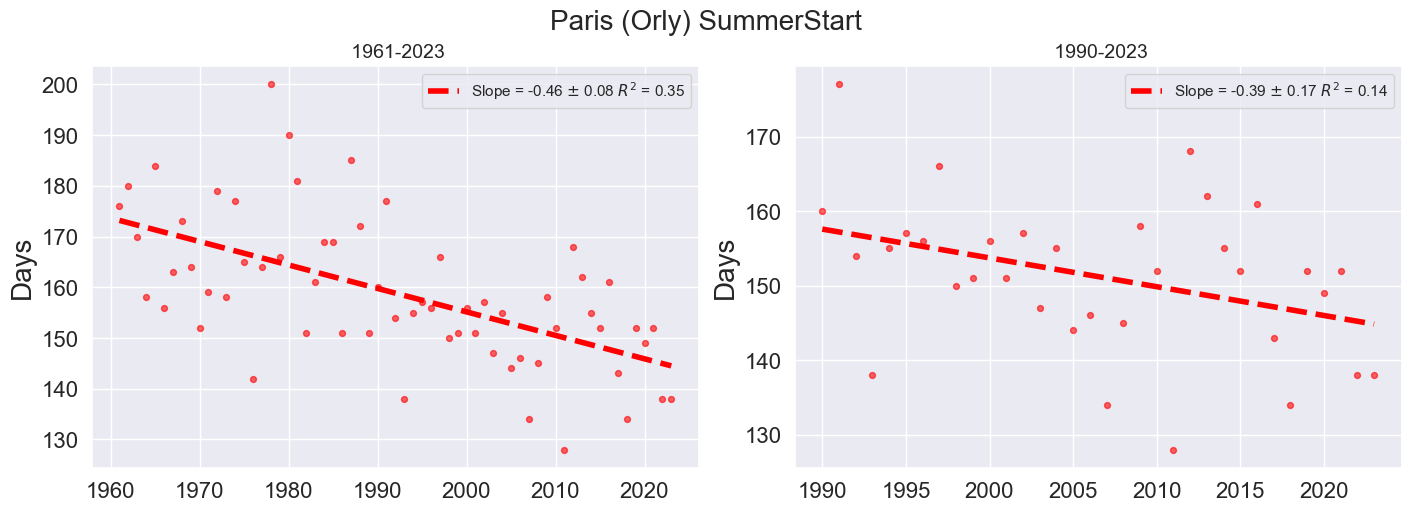

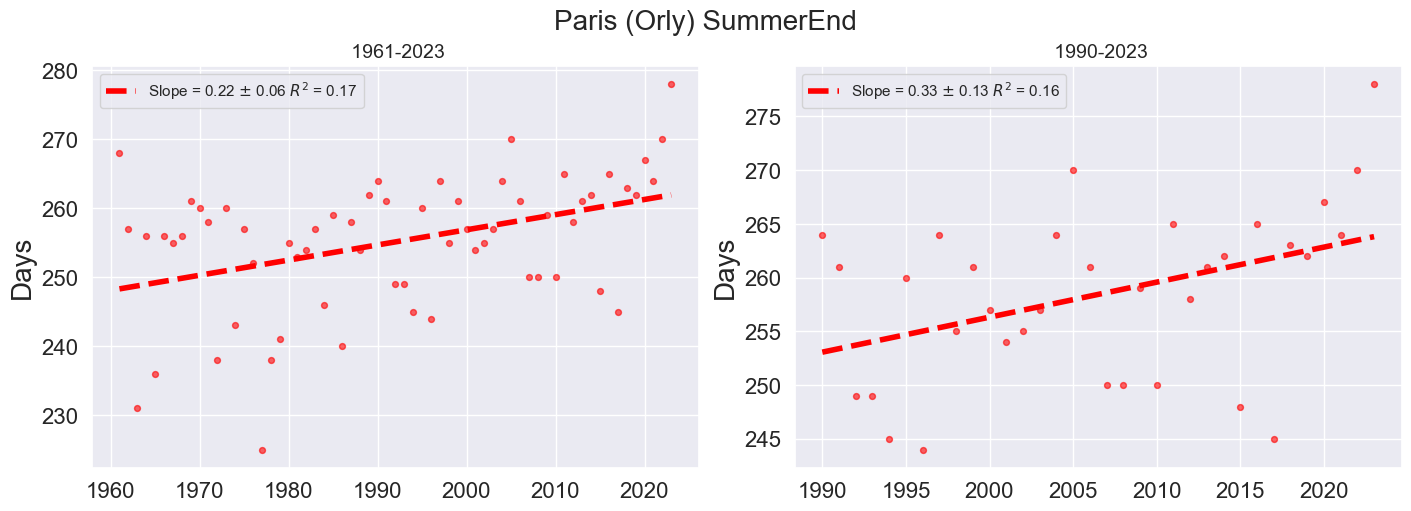

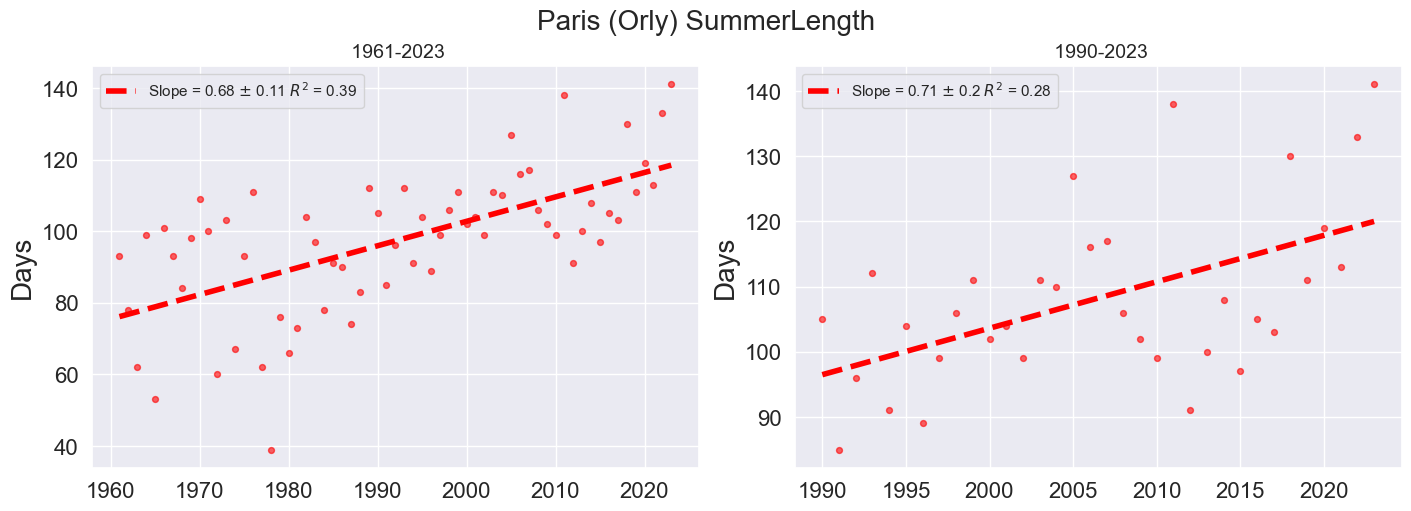

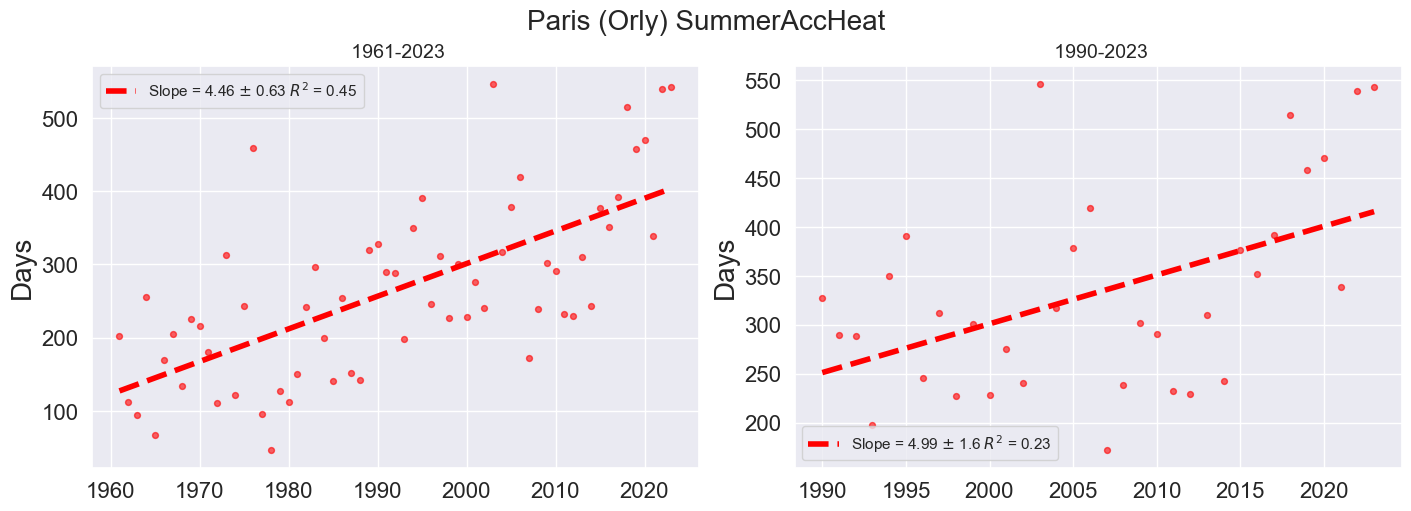

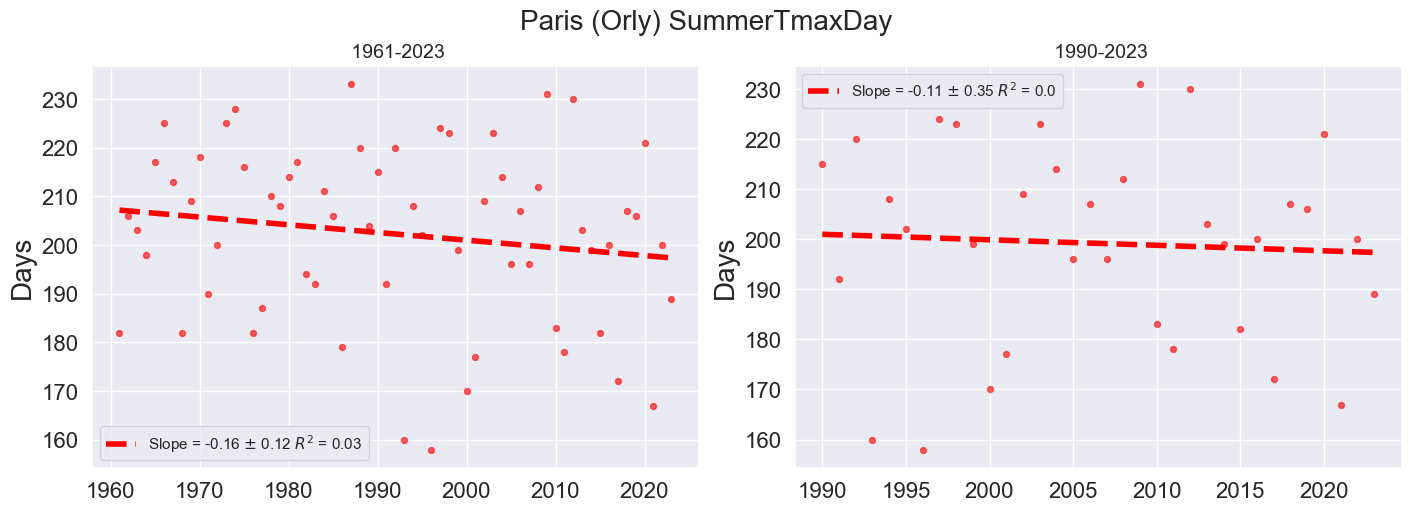

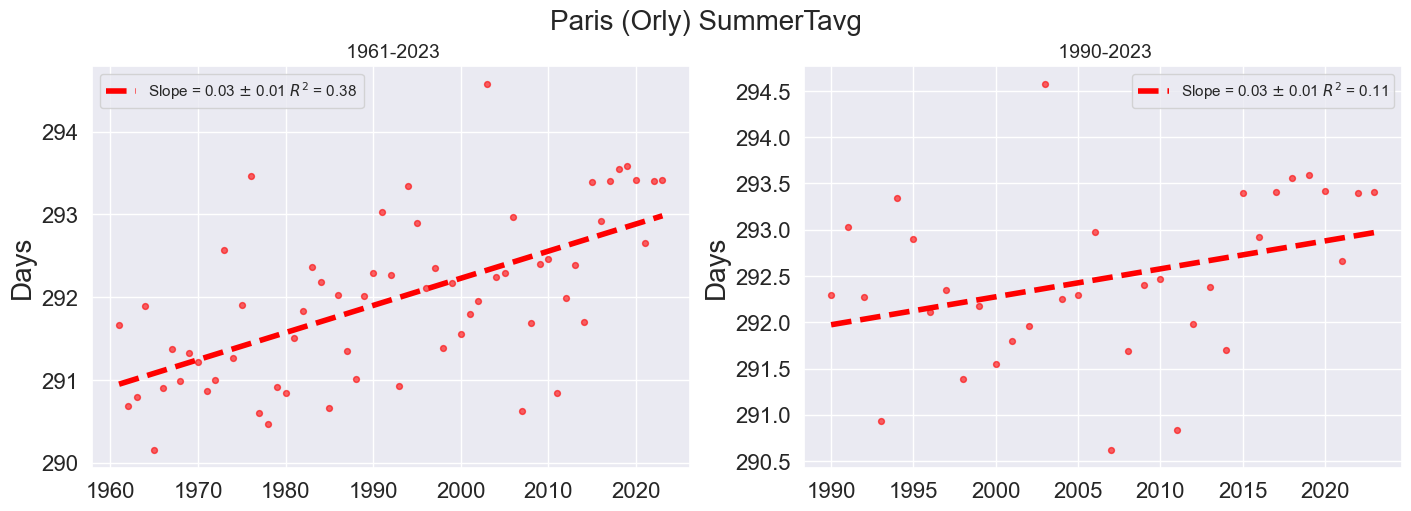

In [361]:
# plot properties so I can more easily tweak them
s = 18
lw = 4
alpha = 0.6
fs = 20
sns.set_theme(style="darkgrid")


# loop through all plot variables
for i,v in enumerate(plot_vars):


    # variables for plot
    x = df_summ.Year
    y = df_summ[v]
    
    # get linear fit and plot it with data
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = np.round(coefs[0],2)
    slope_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    # plot data for full period
    fig = plt.figure(figsize=(14,5), layout='constrained')
    
    ax1 = fig.add_subplot(1,2,1)
    ax1.scatter(x, y, label="", c="red", s=s, alpha=alpha)
    ax1.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='red', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
    plt.suptitle("Paris (Orly) "+v, fontsize=fs)
    ax1.set_title(" 1961-2023", fontsize=14)
    ax1.legend(loc="best")
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    ax1.set_ylabel('Days', fontsize=fs)
    
    
    # analysis period 1990-2023
    # variables for plot
    x = df_summ.Year[df_summ.Year >= 1990]
    y = df_summ[v][df_summ.Year >= 1990]
    
    # get linear fit and plot it with data
    coefs, V = np.polyfit(x, y, 1, cov=True)
    poly = np.poly1d(coefs)
    slope = np.round(coefs[0],2)
    slope_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y)
    ss_total = np.sum((y - ymean)**2)
    ss_res = np.sum((y - poly(x))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared = np.round(1 - (ss_res / ss_total),2)
    
    ax2 = fig.add_subplot(1,2,2)
    ax2.scatter(x, y, label="", c="red", s=s, alpha=alpha)
    ax2.plot(x, poly(x), linestyle="dashed", linewidth=lw, color='red', 
         label="Slope = "+str(slope)+" $\pm$ "+str(slope_sd)+" $R^2$ = "+str(r_squared))
    ax2.set_title(" 1990-2023", fontsize=14)
    ax2.legend(loc="best")
    ax2.tick_params('x', labelsize=16)
    ax2.tick_params('y', labelsize=16)
    ax2.set_ylabel('Days', fontsize=fs)
    
